# Topology Optimization Methods Comparison

This notebook compares final objectives across different methods:
- **ADMM methods** (3 variants): admm, admm_distributed_tv, admm_switching
- **Deterministic methods**: FEM (relax_and_round), FEniCS (simp_adjoint)

For each mesh size (16, 32, 64, 128), we plot:
- ADMM methods: quantile boxes showing median and quartiles across random seeds
- FEM: triangle markers for continuous and discrete objectives
- FEniCS: square markers for discrete objectives

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

# Add method directories to path
sys.path.insert(0, os.path.join(os.getcwd(), 'admm1'))
sys.path.insert(0, os.path.join(os.getcwd(), 'admm_colin'))
sys.path.insert(0, os.path.join(os.getcwd(), 'admm2'))
sys.path.insert(0, os.path.join(os.getcwd(), 'admm_gpy'))
sys.path.insert(0, os.path.join(os.getcwd(), 'admm_no_simp'))
sys.path.insert(0, os.path.join(os.getcwd(), 'admm_distributed_tv_no_simp'))
sys.path.insert(0, os.path.join(os.getcwd(), 'relax_and_round_exact'))
sys.path.insert(0, os.path.join(os.getcwd(), 'relax_and_round_smooth'))

# Import visualization modules
from admmviz import ADMM
from admm2viz import ADMM2
#from admmgpyviz import ADMMGpy
#from admmnosimpviz import ADMMNoSIMP
from admmcolinviz import ADMMColin
#from admmdistTVnosimpviz import ADMMDistTVNoSIMP
from femviz import femModel
from fenicsviz import fenicsModel

# # Import admm_colin admmviz
# import importlib.util
# spec = importlib.util.spec_from_file_location("admmviz_colin", os.path.join(os.getcwd(), 'admm_colin', 'admmviz.py'))
# admmviz_colin = importlib.util.module_from_spec(spec)
# #spec.loader.exec_module(admmviz_colin)
# ADMM_Colin = admmviz_colin.ADMM

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [26]:
# admmcolin = ADMMColin(alpha=1.0, dim=64, base_dir='admm_colin/run_data_admm_gurobi')
# admmcolin.objective_disc

## Helper Functions

In [25]:
def get_admm_final_objectives(alpha, dim, base_dir, suffix="", infeas_threshold=100):
    """
    Get final objective values for ADMM across all seeds, but ONLY include seeds
    whose final infeasibility (last entry of infeas_list) is < infeas_threshold.

    Returns:
        np.ndarray of filtered final objectives, or None if file missing or no valid seeds.
    """
    try:
        print(f"Loading ADMM data from {base_dir} with suffix '{suffix}' for alpha={alpha}, dim={dim}...")
        base = f"{base_dir}_{suffix}" if suffix else base_dir
        h5_path = os.path.join(base, str(alpha), f"{dim}.h5")

        if not os.path.exists(h5_path):
            return None

        objectives = []
        with h5py.File(h5_path, 'r') as h5f:
            for key in h5f.keys():
                if not key.startswith('seed_'):
                    continue

                grp = h5f[key]

                # Need both lists
                if ('objective_list' not in grp) or ('infeas_list' not in grp):
                    continue

                obj_list = grp['objective_list'][:]
                infeas_list = grp['infeas_list'][:]

                if len(obj_list) == 0 or len(infeas_list) == 0:
                    continue

                final_obj = float(obj_list[-1])
                final_infeas = float(infeas_list[-1])
                print(f"Seed {key}: final_obj={final_obj}, final_infeas={final_infeas}")

                # Filter rule
                if final_infeas < infeas_threshold:
                    objectives.append(final_obj)

        return np.array(objectives) if objectives else None

    except Exception as e:
        print(f"Error loading ADMM data for {base_dir}, alpha={alpha}, dim={dim}: {e}")
        return None


def get_fem_objectives(alpha, n):
    """
    Get FEM continuous and discrete objectives.
    Returns (cont_obj, disc_obj) or (None, None) if file doesn't exist.
    """
    try:
        fm = femModel(alpha=alpha, n=n, base_dir='relax_and_round_exact/fem_model_tri')
        return fm.objective_cont, fm.objective
    except Exception as e:
        print(f"Error loading FEM data for alpha={alpha}, n={n}: {e}")
        return None, None

def get_admm_gpy_objectives(obj, alpha, dim, base_dir='admm_gpy/run_data_admm_gurobi', suffix="method", infeas_threshold=100):
    """
    Get final objective values for ADMM with Gurobi across all seeds.
    Returns np.ndarray of objectives or None if file doesn't exist.
    """
    try:
        #agpy = obj(alpha=alpha, dim=dim, base_dir=base_dir)
        #return fm.compliance + 1/n * (alpha*fm.tv)
        return obj.trial(0).series.objective_disc[-1]
    except Exception as e:
        print(f"Error loading ", str(suffix) ,f" data for alpha={alpha}, n={dim}: {e}")
        return None

    except Exception as e:
        print(f"Error loading ", str(suffix) ,f" data for {base_dir}, alpha={alpha}, dim={dim}: {e}")
        return None


def get_fenics_objective(alpha, n, seed=0):
    """
    Get FEniCS discrete objective.
    Returns objective or None if file doesn't exist.
    """
    try:
        fm = fenicsModel(alpha=alpha, n=n, seed=seed, base_dir='relax_and_round_smooth/fenics_model_tri')
        #return fm.compliance + 1/n * (alpha*fm.tv)
        return fm.objective
    except Exception as e:
        print(f"Error loading FEniCS data for alpha={alpha}, n={n}: {e}")
        return None


def compute_quantiles(data, quantiles=[0.25, 0.5, 0.75]):
    """
    Compute quantiles from data array.
    Returns dict with quantile values.
    """
    if data is None or len(data) == 0:
        return None
    return {q: np.quantile(data, q) for q in quantiles}

## Main Plotting Function

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch, Rectangle

def _set_obj_comp_style():
    base_rc = {
        "figure.dpi": 120,
        "lines.linewidth": 2.8,
        "lines.markersize": 5,
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "legend.fontsize": 11,
    }
    try:
        import seaborn as sns
        sns.set_theme(style="darkgrid")
        mpl.rcParams.update(base_rc)
    except Exception:
        mpl.rcParams.update(base_rc)

def plot_obj(alpha, mesh_sizes=[16,32,64,128], figsize=(14, 8)):
    """
    Create comparison plot for a given alpha value.
    """
    _set_obj_comp_style()

    admm_methods_gpy = [
        {'name': 'ADMM-NC', 'base_dir': 'admm1/run_data_admm_gurobi_great', 'suffix': '',  'color': '#3498db'},
        {'name': 'ADMM-NC2', 'base_dir': 'admm2/run_data_admm_gurobi', 'suffix': '', 'color': '#e74c3c'},
        {'name': 'ADMM-ConLin', 'base_dir': 'admm_colin/run_data_admm_gurobi_great', 'suffix': '', 'color': "#069494"}
    ]
    
    admm_methods_ms = [
        {'name': 'ADMM-NC', 'base_dir': 'admm1/run_data_admm_mergesplit', 'suffix': '',  'color': '#3498db'},
        {'name': 'ADMM-NC2', 'base_dir': 'admm2/run_data_admm_mergesplit', 'suffix': '', 'color': '#e74c3c'},
        {'name': 'ADMM-ConLin', 'base_dir': 'admm_colin/run_data_mergesplit', 'suffix': '', 'color': "#069494"}
    ]

    # Use a qualitative, colorblind-friendly palette (tab10).
    cmap = plt.get_cmap("tab10")
    for i, method in enumerate(admm_methods_ms):
        method["color"] = cmap(i % cmap.N)
    for i, method in enumerate(admm_methods_gpy):
        method["color"] = cmap((i + len(admm_methods_ms)) % cmap.N)

    fig, ax = plt.subplots(figsize=figsize)

    x_positions = np.arange(len(mesh_sizes))
    x_labels = [f'Mesh {m}' for m in mesh_sizes]

    box_width = 0.10
    method_spacing = 0.16

    handles, labels = [], []

    median_data = {m['name']: [] for m in admm_methods_ms}
    
    outliers = {}
    for method_idx, method in enumerate(admm_methods_ms):
        print(f"\nProcessing {method['name']}...")

        name = method["name"]
        outliers.setdefault(name, {})
        
        for mesh_idx, mesh_size in enumerate(mesh_sizes):
            try:
                if name == 'ADMM-CONLIN':
                    obj = ADMMColin(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                elif name == 'ADMM-1(SIMP)':
                    obj = ADMM(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                elif name == 'ADMM-2(SIMP)':
                    obj = ADMM2(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                
                objectives = get_admm_final_objectives(
                    obj=obj,
                    alpha=alpha,
                    dim=mesh_size,
                    base_dir=method['base_dir'],
                    suffix=method['suffix'],
                    infeas_threshold=500)
            except Exception as e:
                print(f"Error loading ", str(method['suffix']) ,f" data for alpha={alpha}, n={mesh_size}: {e}")
                objectives = None 

            if objectives is None or len(objectives) == 0:
                print(f"  Mesh {mesh_size}: No valid seeds after infeasibility filter (infeas < {mesh_size}).")
                continue

            objectives = np.asarray(objectives, dtype=float)

            pos = objectives > 0
            if not np.all(pos):
                bad = np.sum(~pos)
                print(f"  Mesh {mesh_size}: WARNING {bad}/{len(objectives)} objectives <= 0 (cannot plot on log y). Filtering them out.")
                objectives = objectives[pos]

            if len(objectives) == 0:
                print(f"  Mesh {mesh_size}: All objectives were <= 0 after filtering; skipping.")
                continue

            q25, q50, q75 = np.percentile(objectives, [25, 50, 75])

            iqr = q75 - q25
            low_fence  = q25 - 1.5 * iqr
            high_fence = q75 + 1.5 * iqr

            inlier = (objectives >= low_fence) & (objectives <= high_fence)
            low_whisk  = objectives[inlier].min()
            high_whisk = objectives[inlier].max()

            offset = (method_idx - 1) * method_spacing
            x_center = x_positions[mesh_idx] + offset

            median_data[name].append((x_center, q50))

            rect = Rectangle(
                (x_center - box_width/2, q25),
                box_width,
                max(q75 - q25, 1e-300),
                facecolor=method['color'],
                alpha=0.55,
                edgecolor=method['color'],
                linewidth=1.8,
                zorder=5
            )
            ax.add_patch(rect)

            ax.plot(
                [x_center - box_width/2, x_center + box_width/2],
                [q50, q50],
                color='black',
                linewidth=2.2,
                zorder=6
            )
            
            ax.plot([x_center, x_center], [low_whisk, q25], color=method['color'], linewidth=1.8, zorder=4)
            ax.plot([x_center, x_center], [q75, high_whisk], color=method['color'], linewidth=1.8, zorder=4)

            cap = box_width * 0.8
            ax.plot([x_center - cap/2, x_center + cap/2], [low_whisk, low_whisk], color=method['color'], linewidth=1.8, zorder=4)
            ax.plot([x_center - cap/2, x_center + cap/2], [high_whisk, high_whisk], color=method['color'], linewidth=1.8, zorder=4)

            out = ~inlier
            if np.any(out):
                jitter = (np.random.rand(out.sum()) - 0.5) * box_width * 0.6
                ax.scatter(x_center + jitter, objectives[out], s=18, marker='o',
                        color=method['color'], edgecolors='black', linewidths=0.4,
                        alpha=0.9, zorder=7)
            
            outliers[name][mesh_size] = np.where(out)[0]

            print(f"  Mesh {mesh_size}: {len(objectives)} seeds (plotted), q25={q25:.6g}, median={q50:.6g}, q75={q75:.6g}")

        if len(median_data[name]) > 0:
            handles.append(Patch(facecolor=method['color'], alpha=0.55, edgecolor=method['color'], linewidth=1.8))
            labels.append(method['name'])
        else:
            print(f"  {method['name']}: No valid data across all mesh sizes; omitting from legend.")

    print("\nProcessing FEM (Relax and Round)...")
    fem_cont_objs, fem_disc_objs, fem_x_positions = [], [], []

    for mesh_idx, mesh_size in enumerate(mesh_sizes):
        cont_obj, disc_obj = get_fem_objectives(alpha=alpha, n=mesh_size)
        if cont_obj is not None:
            fem_cont_objs.append(cont_obj)
            fem_disc_objs.append(disc_obj)
            fem_x_positions.append(x_positions[mesh_idx])
            print(f"  Mesh {mesh_size}: cont={cont_obj:.6g}, disc={disc_obj:.6g}")
        else:
            print(f"  Mesh {mesh_size}: No data")

    if fem_cont_objs:
        ax.scatter(fem_x_positions, fem_disc_objs, marker='v', s=120,
                   color='#8e44ad', edgecolors='black', linewidths=1.3,
                   label='R&R exact', zorder=10)

    print("\nProcessing FEniCS (SIMP Adjoint)...")
    fenics_objs, fenics_x_positions = [], []

    for mesh_idx, mesh_size in enumerate(mesh_sizes):
        obj = get_fenics_objective(alpha=alpha, n=mesh_size)
        if obj is not None:
            fenics_objs.append(obj)
            fenics_x_positions.append(x_positions[mesh_idx])
            print(f"  Mesh {mesh_size}: obj={obj:.6g}")
        else:
            print(f"  Mesh {mesh_size}: No data")

    if fenics_objs:
        ax.scatter(fenics_x_positions, fenics_objs, marker='s', s=120,
                   color='#f39c12', edgecolors='black', linewidths=1.3,
                   label='R&R smooth', zorder=10)
        
    
    print("\nProcessing ADMM Gurobi...")

    for method_idx, method in enumerate(admm_methods_gpy):
        print(f"\nProcessing {method['name']}...")
        agpy_objs, agpy_x_positions = [], []

        name = method["name"]
        outliers.setdefault(name, {})
        
        for mesh_idx, mesh_size in enumerate(mesh_sizes):
            try:
                if name == 'ADMM-ConLin':
                    admmobj = ADMMColin(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                elif name == 'ADMM-NC':
                    admmobj = ADMM(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                elif name == 'ADMM-NC2':
                    admmobj = ADMM2(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                objective = get_admm_gpy_objectives(
                    obj=admmobj,
                    alpha=alpha,
                    dim=mesh_size,
                    base_dir=method['base_dir'],
                    suffix=method['suffix'],
                    infeas_threshold=500)
            except Exception as e:
                print(f"Error loading ", str(method['suffix']) ,f" data for alpha={alpha}, n={mesh_size}: {e}")
                objective = None
            if objective is not None:
                agpy_objs.append(objective)
                agpy_x_positions.append(x_positions[mesh_idx])
            else:
                print(f"  {mesh_size}: No data")
                    
        if agpy_objs:
            ax.scatter(agpy_x_positions, agpy_objs, marker='D', s=120,
                    color=method['color'], edgecolors=method['color'], linewidths=1.3,
                    label=method['name'], zorder=5)
                

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=16)

    ax.set_xlabel('Mesh Size', fontsize=16, fontweight='bold')
    ax.set_ylabel('Final Objective Value', fontsize=16, fontweight='bold')
    ax.set_title(f'Objective values (alpha = {alpha})',
                 fontsize=16, fontweight='bold', pad=20)
    ax.tick_params(axis='y', which='both')

    ax.set_yscale('log')

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)

    ax.set_xlim(-0.6, len(mesh_sizes) - 0.4)

    admm_handles = handles
    admm_labels = labels

    auto_handles, auto_labels = ax.get_legend_handles_labels()

    all_handles = admm_handles + auto_handles
    all_labels  = admm_labels  + auto_labels

    ax.legend(all_handles, all_labels,
            loc='upper center', bbox_to_anchor=(0.5, -0.18),
            ncol=10, fontsize=18, frameon=True, shadow=True)

    plt.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()

    print(f"\n{'='*60}")
    print(f"Plot completed for alpha = {alpha}")
    print(f"{'='*60}")
    
    return outliers

## Usage Examples

Call the `plot(alpha)` function with your desired alpha value:


Processing ADMM-NC...
Error loading    data for alpha=0.01, n=16: cannot access local variable 'obj' where it is not associated with a value
  Mesh 16: No valid seeds after infeasibility filter (infeas < 16).
Error loading    data for alpha=0.01, n=32: cannot access local variable 'obj' where it is not associated with a value
  Mesh 32: No valid seeds after infeasibility filter (infeas < 32).
Error loading    data for alpha=0.01, n=64: cannot access local variable 'obj' where it is not associated with a value
  Mesh 64: No valid seeds after infeasibility filter (infeas < 64).
Error loading    data for alpha=0.01, n=128: cannot access local variable 'obj' where it is not associated with a value
  Mesh 128: No valid seeds after infeasibility filter (infeas < 128).
  ADMM-NC: No valid data across all mesh sizes; omitting from legend.

Processing ADMM-NC2...
Error loading    data for alpha=0.01, n=16: cannot access local variable 'obj' where it is not associated with a value
  Mesh 16: No

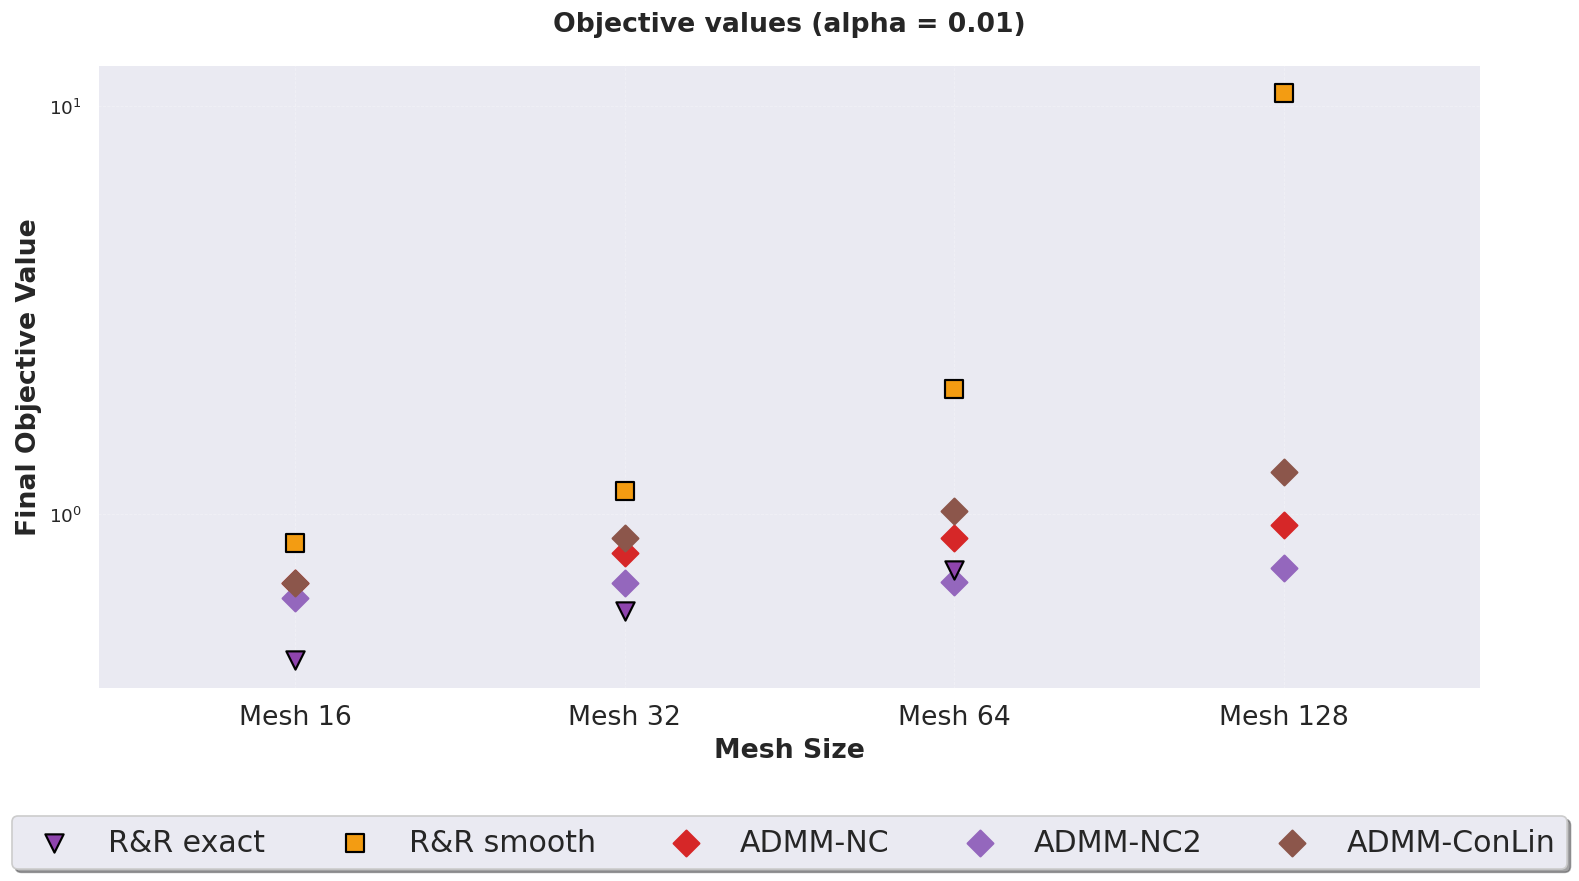


Plot completed for alpha = 0.01


In [27]:
# Example: Plot for alpha = 0.01
outliers_1e2 = plot_obj(alpha=0.01)


Processing ADMM-NC...
Error loading    data for alpha=0.1, n=16: cannot access local variable 'obj' where it is not associated with a value
  Mesh 16: No valid seeds after infeasibility filter (infeas < 16).
Error loading    data for alpha=0.1, n=32: cannot access local variable 'obj' where it is not associated with a value
  Mesh 32: No valid seeds after infeasibility filter (infeas < 32).
Error loading    data for alpha=0.1, n=64: cannot access local variable 'obj' where it is not associated with a value
  Mesh 64: No valid seeds after infeasibility filter (infeas < 64).
Error loading    data for alpha=0.1, n=128: cannot access local variable 'obj' where it is not associated with a value
  Mesh 128: No valid seeds after infeasibility filter (infeas < 128).
  ADMM-NC: No valid data across all mesh sizes; omitting from legend.

Processing ADMM-NC2...
Error loading    data for alpha=0.1, n=16: cannot access local variable 'obj' where it is not associated with a value
  Mesh 16: No vali

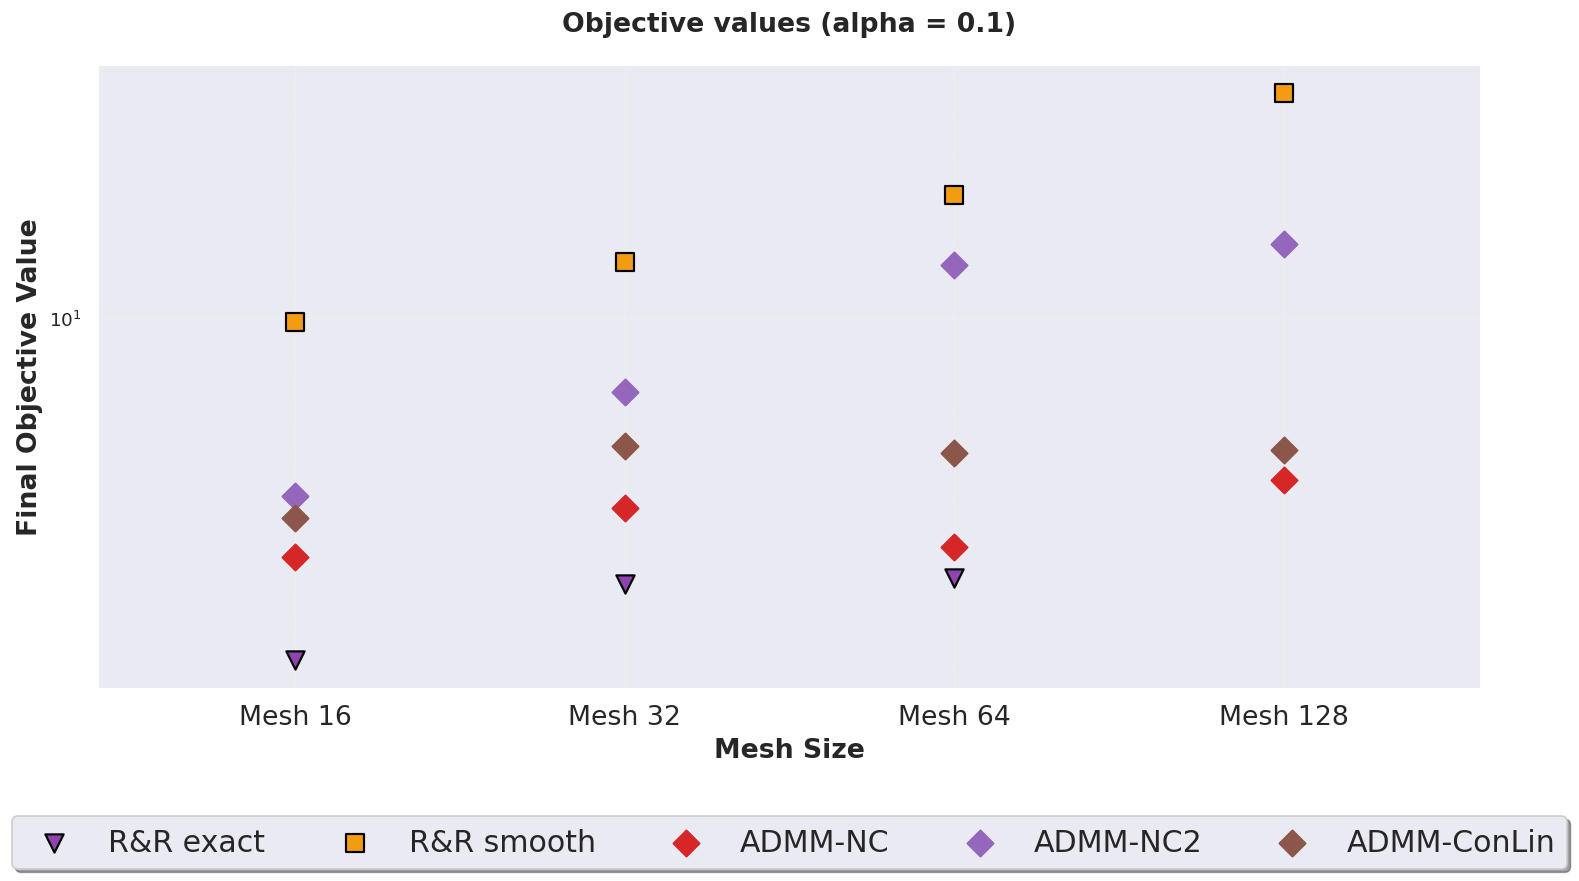


Plot completed for alpha = 0.1


In [28]:
# Example: Plot for alpha = 1e-1
outliers_1e1 = plot_obj(alpha=0.1)


Processing ADMM-1(SIMP)...
Error loading    data for alpha=1.0, n=16: H5 file not found: admm1/run_data_admm_mergesplit/1.0/16.h5
  Mesh 16: No valid seeds after infeasibility filter (infeas < 16).
Error loading    data for alpha=1.0, n=32: H5 file not found: admm1/run_data_admm_mergesplit/1.0/32.h5
  Mesh 32: No valid seeds after infeasibility filter (infeas < 32).
Error loading    data for alpha=1.0, n=64: H5 file not found: admm1/run_data_admm_mergesplit/1.0/64.h5
  Mesh 64: No valid seeds after infeasibility filter (infeas < 64).
Error loading    data for alpha=1.0, n=128: H5 file not found: admm1/run_data_admm_mergesplit/1.0/128.h5
  Mesh 128: No valid seeds after infeasibility filter (infeas < 128).
  ADMM-1(SIMP): No valid data across all mesh sizes; omitting from legend.

Processing ADMM-2(SIMP)...
Error loading    data for alpha=1.0, n=16: H5 file not found: admm2/run_data_admm_mergesplit/1.0/16.h5
  Mesh 16: No valid seeds after infeasibility filter (infeas < 16).
Error load

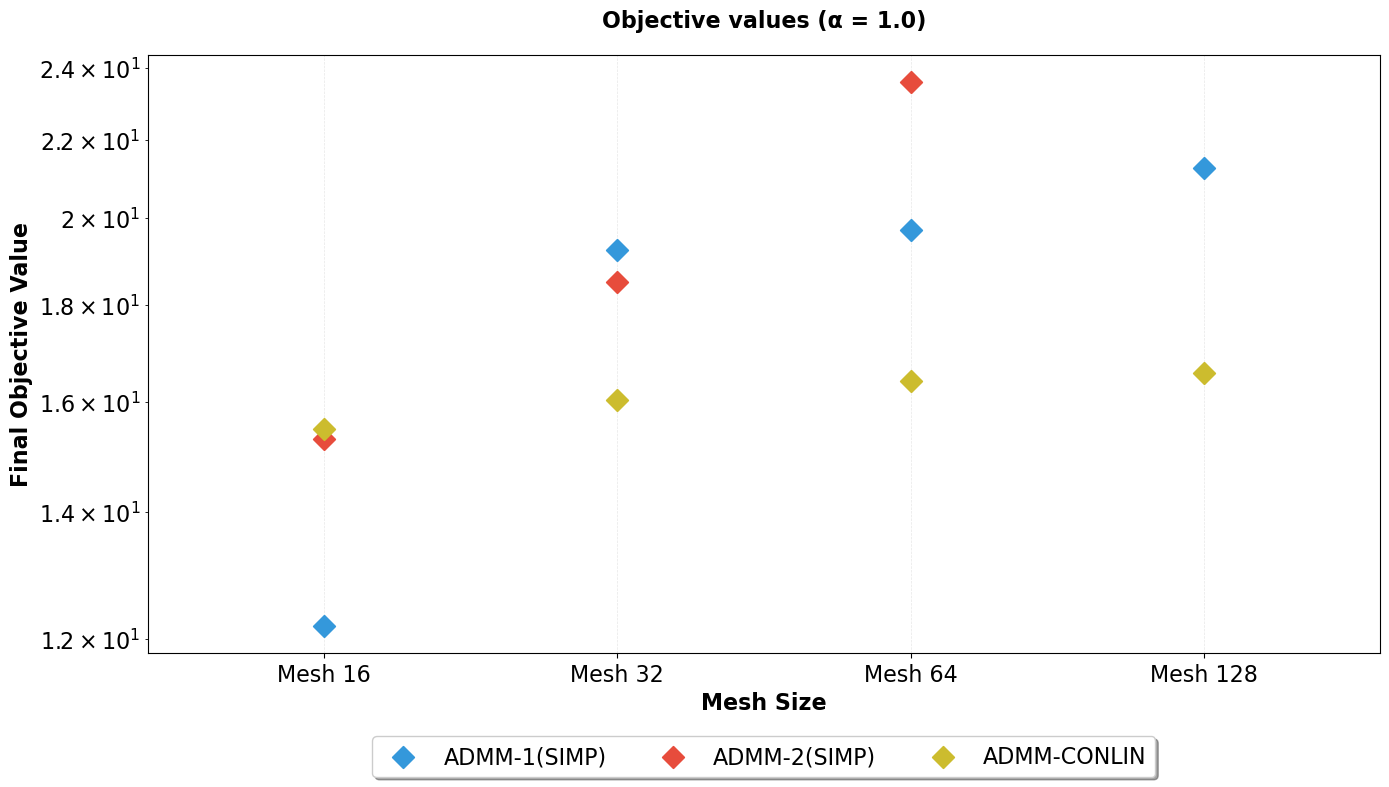


Plot completed for alpha = 1.0


In [49]:
# Example: Plot for alpha = 1
outliers_1  = plot_obj(alpha=1.0)

In [142]:
# Objective/Infeasibility trajectories helper: individual plot per ADMM object
import numpy as np
import matplotlib.pyplot as plt

def _normalize_y_axis(y_axis):
    """Map user input to a supported trial series name."""
    key = str(y_axis).strip().lower()
    if key in {"objective", "obj"}:
        return "objective"
    if key in {"infeasibility", "infeas", "infeasible", "infeas_list"}:
        return "infeas"
    if key in {"objective/infeasibility", "infeasibility/objective"}:
        return "objective"
    raise ValueError("y_axis must be one of: 'objective', 'infeasibility'")

def _extract_series_from_trial(trial, y_axis_key):
    """Return requested 1D series from trial.series with a few fallback names."""
    if y_axis_key == "objective":
        return np.asarray(trial.series.objective, dtype=float)

    for attr in ("infeas", "infeasibility", "infeas_list"):
        if hasattr(trial.series, attr):
            return np.asarray(getattr(trial.series, attr), dtype=float)

    raise AttributeError("Requested infeasibility series not found in trial.series")

def _extract_funnel_from_trial(trial):
    """Return funnel width series if available."""
    for attr in ("funnel", "funnel_width", "funnel_list"):
        if hasattr(trial.series, attr):
            return np.asarray(getattr(trial.series, attr), dtype=float)

    raise AttributeError("Funnel width series not found in trial.series")

def _collect_series_runs(admm_obj, seeds, y_axis="objective", clip_first_n=None, plot_funnel=False):
    """Collect variable-length series[1:] arrays for available seeds."""
    y_axis_key = _normalize_y_axis(y_axis)
    runs = []
    funnel_runs = []
    used_seeds = []

    for s in seeds:
        try:
            trial = admm_obj.trial(s)
            series = _extract_series_from_trial(trial, y_axis_key)

            if clip_first_n is not None:
                series = series[:clip_first_n]

            vals = series[1:]
            if vals.size == 0:
                continue

            runs.append(vals)

            if plot_funnel and y_axis_key == "infeas":
                try:
                    funnel = _extract_funnel_from_trial(trial)
                    if clip_first_n is not None:
                        funnel = funnel[:clip_first_n]
                    funnel_runs.append(funnel[1:])
                except Exception:
                    funnel_runs.append(np.array([], dtype=float))

            used_seeds.append(s)
        except Exception:
            continue

    return runs, funnel_runs, used_seeds, y_axis_key

def _per_iteration_stats(runs):
    """Compute min/median/max at each iteration without truncating run lengths."""
    if not runs:
        return None, None, None, None

    max_len = max(len(r) for r in runs)
    y_min = np.full(max_len, np.nan, dtype=float)
    y_med = np.full(max_len, np.nan, dtype=float)
    y_max = np.full(max_len, np.nan, dtype=float)

    for i in range(max_len):
        vals = [r[i] for r in runs if i < len(r)]
        if vals:
            vals = np.asarray(vals, dtype=float)
            y_min[i] = np.min(vals)
            y_med[i] = np.median(vals)
            y_max[i] = np.max(vals)

    iters = np.arange(max_len)
    return iters, y_min, y_med, y_max

def _per_iteration_max(runs):
    """Compute per-iteration max over available runs."""
    if not runs:
        return None, None

    max_len = max((len(r) for r in runs), default=0)
    if max_len == 0:
        return None, None

    y_max = np.full(max_len, np.nan, dtype=float)
    for i in range(max_len):
        vals = [r[i] for r in runs if i < len(r) and np.isfinite(r[i])]
        if vals:
            y_max[i] = np.max(np.asarray(vals, dtype=float))

    iters = np.arange(max_len)
    return iters, y_max

def _build_deterministic_obj(admm_obj, deterministic_base_dir="run_data_admm_gurobi"):
    """Build deterministic wrapper of the same class from a fixed base directory."""
    cls = admm_obj.__class__
    alpha = float(getattr(admm_obj, "alpha"))
    dim = int(getattr(admm_obj, "dim"))
    suffix = str(getattr(admm_obj, "suffix", ""))

    try:
        return cls(alpha=alpha, dim=dim, base_dir=deterministic_base_dir)
    except TypeError:
        return cls(alpha=alpha, dim=dim, suffix=suffix, base_dir=deterministic_base_dir)

def _collect_deterministic_series(admm_obj, y_axis="objective", clip_first_n=None, deterministic_base_dir="run_data_admm_gurobi"):
    """Collect deterministic trajectory from trial(0)."""
    y_axis_key = _normalize_y_axis(y_axis)
    det_obj = _build_deterministic_obj(admm_obj, deterministic_base_dir=deterministic_base_dir)
    trial = det_obj.trial(0)
    series = _extract_series_from_trial(trial, y_axis_key)
    if clip_first_n is not None:
        series = series[:clip_first_n]
    vals = np.asarray(series[1:], dtype=float)
    if vals.size == 0:
        raise ValueError("Deterministic series is empty after clipping")
    return vals

def plot(
    admm_obj,
    name=None,
    seeds=None,
    color="#3498db",
    clip_first_n=None,
    figsize=(7, 5),
    y_axis="objective",
    plot_funnel=False,
    funnel_color=None,
    funnel_linestyle="--",
    plot_deterministic=False,
    deterministic_base_dir="run_data_admm_gurobi",
):
    """
    Plot min-max envelope and median across random seeds, with optional deterministic overlay.

    Parameters
    ----------
    admm_obj : object
        ADMM wrapper object with trial(seed).series access.
    y_axis : str
        'objective' or 'infeasibility'.
    plot_funnel : bool
        If True and y_axis='infeasibility', overlay max funnel width as dashed line.
    plot_deterministic : bool
        If True, also plot deterministic trajectory from trial(0) loaded from deterministic_base_dir.
    deterministic_base_dir : str
        Base directory for deterministic data (default: run_data_admm_gurobi).
    """
    if seeds is None:
        seeds = seeds_to_try

    y_axis_key = _normalize_y_axis(y_axis)
    y_label = "Objective" if y_axis_key == "objective" else "Infeasibility"

    if name is None:
        name = admm_obj.__class__.__name__

    runs, funnel_runs, used, y_axis_key = _collect_series_runs(
        admm_obj,
        seeds,
        y_axis=y_axis_key,
        clip_first_n=clip_first_n,
        plot_funnel=plot_funnel,
    )

    deterministic_vals = None
    if plot_deterministic:
        try:
            deterministic_vals = _collect_deterministic_series(
                admm_obj,
                y_axis=y_axis_key,
                clip_first_n=clip_first_n,
                deterministic_base_dir=deterministic_base_dir,
            )
        except Exception as e:
            print(f"Could not load deterministic data: {e}")

    fig, ax = plt.subplots(figsize=figsize)

    plotted_any = False
    x_max = 1
    all_positive = True

    if runs and not plot_deterministic:
        iters, y_min, y_med, y_max = _per_iteration_stats(runs)
        valid = np.isfinite(y_min) & np.isfinite(y_med) & np.isfinite(y_max)

        ax.fill_between(
            iters,
            y_min,
            y_max,
            where=valid,
            interpolate=True,
            color=color,
            alpha=0.22,
            label="Min-Max across seeds",
        )
        ax.plot(iters, y_med, color=color, linewidth=2.8, label="Median")
        plotted_any = True
        x_max = max(x_max, int(np.nanmax(iters)) if len(iters) else 1)

        if np.any(valid):
            all_positive = all_positive and np.all(y_min[valid] > 0)

        if plot_funnel and y_axis_key == "infeas":
            funnel_iters, funnel_max = _per_iteration_max(funnel_runs)
            if funnel_iters is not None and funnel_max is not None:
                funnel_valid = np.isfinite(funnel_max)
                if np.any(funnel_valid):
                    ax.plot(
                        funnel_iters[funnel_valid],
                        funnel_max[funnel_valid],
                        color=funnel_color or "black",
                        linewidth=2.0,
                        linestyle=funnel_linestyle,
                        alpha=0.9,
                        label="Max funnel width",
                    )
                    x_max = max(x_max, int(np.nanmax(funnel_iters[funnel_valid])))
                    all_positive = all_positive and np.all(funnel_max[funnel_valid] > 0)

    if deterministic_vals is not None:
        det_iters = np.arange(len(deterministic_vals))
        det_valid = np.isfinite(deterministic_vals)
        if np.any(det_valid):
            ax.plot(
                det_iters[det_valid],
                deterministic_vals[det_valid],
                color="black",
                linewidth=2.2,
                linestyle="-",
                label="Deterministic",
            )
            plotted_any = True
            x_max = max(x_max, int(np.nanmax(det_iters[det_valid])))
            all_positive = all_positive and np.all(deterministic_vals[det_valid] > 0)

    if not plotted_any:
        ax.text(0.5, 0.5, "No seed/deterministic data found", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{name} - {y_label}", fontsize=16, fontweight="bold", pad=14)
        ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
        plt.tight_layout()
        plt.show()
        return

    if all_positive:
        ax.set_yscale("log")

    ax.set_title(f"{name}", fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("Iteration", fontsize=14, fontweight="bold")
    ax.set_xticks(np.linspace(0, max(x_max, 1), 5, dtype=int))
    x_labels = np.linspace(0, x_max, 5, dtype=int)
    x_labels = [t+1 for t in x_labels]
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.set_ylabel(y_label, fontsize=14, fontweight="bold")
    ax.tick_params(axis="both", which="both", labelsize=12)
    #ax.set_xticks(np.linspace(0, max(x_max, 1), 5, dtype=int))
    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=2,
        fontsize=13,
        frameon=True,
        shadow=True,
    )

    plt.tight_layout()
    plt.show()

# Usage examples:

# plot(
#     ADMMColin(alpha=alpha, dim=dim, base_dir="admm_colin/run_data_admm_mergesplit"),
#     name=f"ADMM-CONLIN (alpha={alpha}, dim={dim})",
#     color="#ccbc2e",
#     seeds=seeds_to_try,
#     figsize=(7, 5),
#     y_axis="objective",
#     plot_deterministic=True,
#     deterministic_base_dir="run_data_admm_gurobi",
# )

# plot(
#     ADMMColin(alpha=alpha, dim=dim, base_dir="admm_colin/run_data_admm_mergesplit"),
#     name=f"ADMM-CONLIN (alpha={alpha}, dim={dim})",
#     color="#ccbc2e",
#     seeds=seeds_to_try,
#     figsize=(7, 5),
#     y_axis="infeasibility",
#     plot_funnel=True,
#     plot_deterministic=True,
#     deterministic_base_dir="run_data_admm_gurobi",
# )

In [143]:
alpha = 1.0
dim = 64
seeds_to_try = list(range(0, 10))

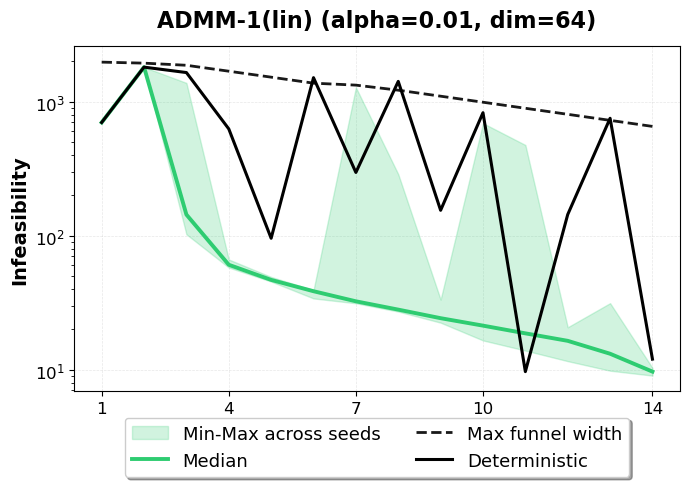

In [10]:
# Example calls (each call makes an individual figure):
plot(
    ADMMNoSIMP(alpha=alpha, dim=dim, base_dir="admm_no_simp/run_data_admm_mergesplit"),
    name=f"ADMM-1(lin) (alpha={alpha}, dim={dim})",
    color="#2ecc71",
    seeds=seeds_to_try,
    figsize=(7, 5),
    y_axis="infeasibility",
    plot_funnel=True,
    plot_deterministic=True,
    deterministic_base_dir="admm_no_simp/run_data_admm_gurobi",
)



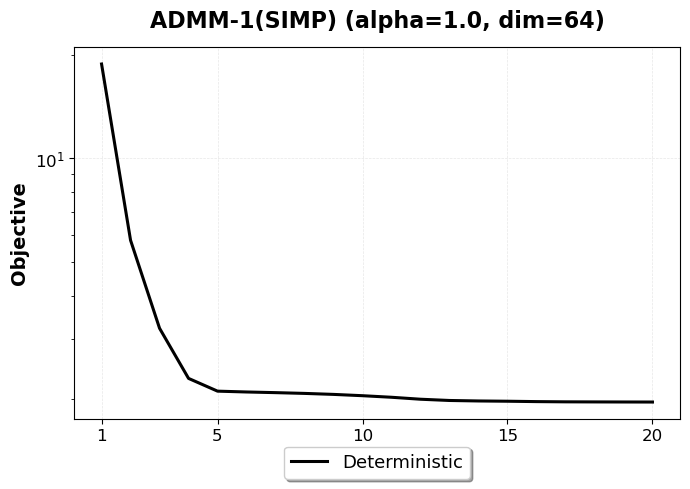

In [144]:
plot(
    ADMM(alpha=alpha, dim=dim, base_dir="admm1/run_data_admm_gurobi"),
    name=f"ADMM-1(SIMP) (alpha={alpha}, dim={dim})",
    color="#3498db",
    seeds=seeds_to_try,
    figsize=(7, 5),
    y_axis="objective",
    plot_funnel=True,
    plot_deterministic=True,
    deterministic_base_dir="admm1/run_data_admm_gurobi",
)

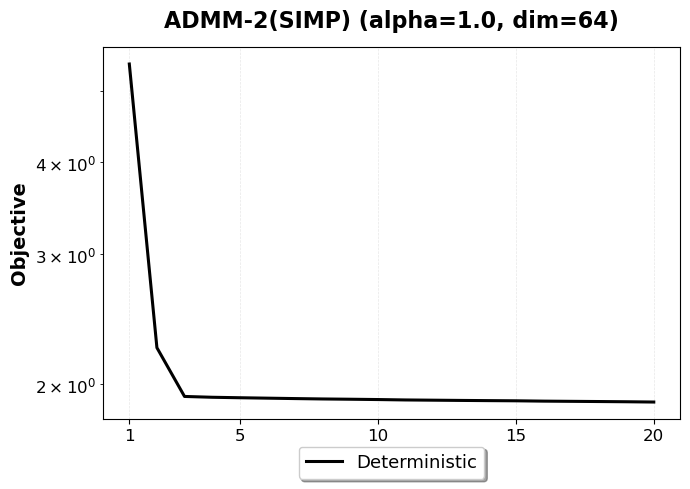

In [145]:
plot(
    ADMM2(alpha=alpha, dim=dim, base_dir="admm2/run_data_admm_gurobi"),
    name=f"ADMM-2(SIMP) (alpha={alpha}, dim={dim})",
    color="#e74c3c",
    seeds=seeds_to_try,
    figsize=(7, 5),
    y_axis="objective",
    plot_funnel=True,
    plot_deterministic=True,
    deterministic_base_dir="admm2/run_data_admm_gurobi"
)

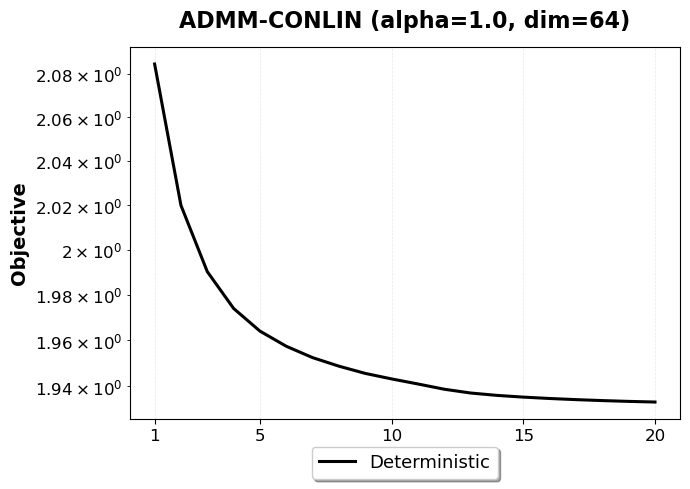

In [146]:
plot(
    ADMMColin(alpha=alpha, dim=dim, base_dir="admm_colin/run_data_admm_gurobi"),
    name=f"ADMM-CONLIN (alpha={alpha}, dim={dim})",
    color="#ccbc2e",
    seeds=seeds_to_try,
    figsize=(7, 5),
    y_axis="objective",
    plot_funnel=True,
    plot_deterministic=True,
    deterministic_base_dir="admm_colin/run_data_admm_gurobi"
)

In [6]:
def get_admm_final_compliance(alpha, dim, base_dir, suffix="", infeas_threshold=100):
    """
    Get final compliance values for ADMM across all seeds, but ONLY include seeds
    whose final infeasibility (last entry of infeas_list) is < infeas_threshold.

    Returns:
        np.ndarray of filtered final compliances, or None if file missing or no valid seeds.
    """
    try:
        print(f"Loading ADMM data from {base_dir} with suffix '{suffix}' for alpha={alpha}, dim={dim}...")
        base = f"{base_dir}_{suffix}" if suffix else base_dir
        h5_path = os.path.join(base, str(alpha), f"{dim}.h5")

        if not os.path.exists(h5_path):
            return None

        compliances = []
        with h5py.File(h5_path, 'r') as h5f:
            for key in h5f.keys():
                if not key.startswith('seed_'):
                    continue

                grp = h5f[key]

                # Need both lists
                if ('compliance_list' not in grp) or ('infeas_list' not in grp):
                    continue

                compliance_list = grp['compliance_list'][:]
                infeas_list = grp['infeas_list'][:]

                if len(compliance_list) == 0 or len(infeas_list) == 0:
                    continue

                final_compliance = float(compliance_list[-1])
                final_infeas = float(infeas_list[-1])
                print(f"Seed {key}: final_compliance={final_compliance}, final_infeas={final_infeas}")

                # Filter rule
                if final_infeas < infeas_threshold:
                    compliances.append(final_compliance)

        return np.array(compliances) if compliances else None

    except Exception as e:
        print(f"Error loading ADMM data for {base_dir}, alpha={alpha}, dim={dim}: {e}")
        return None


def get_fem_compliance(alpha, n):
    """
    Get FEM continuous and discrete objectives.
    Returns (cont_obj, disc_obj) or (None, None) if file doesn't exist.
    """
    try:
        fm = femModel(alpha=alpha, n=n, base_dir='relax_and_round_exact/fem_model_tri')
        return fm.compliance, fm.compliance_cont
    except Exception as e:
        print(f"Error loading FEM data for alpha={alpha}, n={n}: {e}")
        return None, None

def get_admm_gpy_compliance(obj, alpha, dim, base_dir='admm_gpy/run_data_admm_gurobi', suffix="method", infeas_threshold=100):
    """
    Get final compliance values for ADMM with Gurobi across all seeds.
    Returns np.ndarray of compliances or None if file doesn't exist.
    """
    try:
        #agpy = obj(alpha=alpha, dim=dim, base_dir=base_dir)
        #return fm.compliance + 1/n * (alpha*fm.tv)
        return obj.trial(0).series.compliance_disc[-1]
    except Exception as e:
        print(f"Error loading ", str(suffix) ,f" data for alpha={alpha}, n={dim}: {e}")
        return None

    except Exception as e:
        print(f"Error loading ", str(suffix) ,f" data for {base_dir}, alpha={alpha}, dim={dim}: {e}")
        return None


def get_fenics_compliance(alpha, n, seed=0):
    """
    Get FEniCS discrete compliance.
    Returns compliance or None if file doesn't exist.
    """
    try:
        fm = fenicsModel(alpha=alpha, n=n, seed=seed, base_dir='relax_and_round_smooth/fenics_model_tri')
        #return fm.compliance + 1/n * (alpha*fm.tv)
        return fm.compliance
    except Exception as e:
        print(f"Error loading FEniCS data for alpha={alpha}, n={n}: {e}")
        return None


def compute_quantiles(data, quantiles=[0.25, 0.5, 0.75]):
    """
    Compute quantiles from data array.
    Returns dict with quantile values.
    """
    if data is None or len(data) == 0:
        return None
    return {q: np.quantile(data, q) for q in quantiles}

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch, Rectangle

def _set_obj_comp_style():
    base_rc = {
        "figure.dpi": 120,
        "lines.linewidth": 2.8,
        "lines.markersize": 5,
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "legend.fontsize": 11,
    }
    try:
        import seaborn as sns
        sns.set_theme(style="darkgrid")
        mpl.rcParams.update(base_rc)
    except Exception:
        mpl.rcParams.update(base_rc)

def plot_compliance(alpha, mesh_sizes=[16, 32, 64, 128], figsize=(14, 8)):
    """
    Create comparison plot for a given alpha value.
    """
    _set_obj_comp_style()

    admm_methods_ms = [
        {'name': 'ADMM-1(lin)', 'base_dir': 'admm_no_simp/run_data_admm_mergesplit', 'suffix': '', 'color': '#2ecc71'},
        {'name': 'ADMM-1(SIMP)', 'base_dir': 'admm/run_data_admm_mergesplit', 'suffix': '',  'color': '#3498db'},
        {'name': 'ADMM-2(SIMP)', 'base_dir': 'admm_distributed_tv/run_data_admm_dist_tv_mergesplit', 'suffix': '', 'color': '#e74c3c'},
        {'name': 'ADMM-CONLIN', 'base_dir': 'admm_colin/run_data_admm_mergesplit', 'suffix': '', 'color': "#ccbc2e"}
    ]

    admm_methods_gpy = [
        {'name': 'ADMM-NC', 'base_dir': 'admm1/run_data_admm_gurobi_great', 'suffix': '',  'color': '#3498db'},
        {'name': 'ADMM-NC2', 'base_dir': 'admm2/run_data_admm_gurobi', 'suffix': '', 'color': '#069494'},
        {'name': 'ADMM-ConLin', 'base_dir': 'admm_colin/run_data_admm_gurobi_great', 'suffix': '', 'color': "#e74c3c"}
    ]

    cmap = plt.get_cmap("tab10")
    for i, method in enumerate(admm_methods_ms):
        method["color"] = cmap(i % cmap.N)
    for i, method in enumerate(admm_methods_gpy):
        method["color"] = cmap((i + len(admm_methods_ms)) % cmap.N)

    fig, ax = plt.subplots(figsize=figsize)

    x_positions = np.arange(len(mesh_sizes))
    x_labels = [f'Mesh {m}' for m in mesh_sizes]

    box_width = 0.10
    method_spacing = 0.16

    handles, labels = [], []

    median_data = {m['name']: [] for m in admm_methods_ms}

    outliers = {}
    for method_idx, method in enumerate(admm_methods_ms):
        print(f"\nProcessing {method['name']}...")
        
        outliers.setdefault(method["name"], {})
        for mesh_idx, mesh_size in enumerate(mesh_sizes):
            compliance = get_admm_final_compliance(
                alpha=alpha,
                dim=mesh_size,
                base_dir=method['base_dir'],
                suffix=method['suffix'],
                infeas_threshold=mesh_size
            )

            if compliance is None or len(compliance) == 0:
                print(f"  Mesh {mesh_size}: No valid seeds after infeasibility filter (infeas < {mesh_size}).")
                continue

            compliance = np.asarray(compliance, dtype=float)

            pos = compliance > 0
            if not np.all(pos):
                bad = np.sum(~pos)
                print(f"  Mesh {mesh_size}: WARNING {bad}/{len(compliance)} compliance <= 0 (cannot plot on log y). Filtering them out.")
                compliance = compliance[pos]

            if len(compliance) == 0:
                print(f"  Mesh {mesh_size}: All compliances were <= 0 after filtering; skipping.")
                continue

            q25, q50, q75 = np.percentile(compliance, [25, 50, 75])

            iqr = q75 - q25
            low_fence  = q25 - 1.5 * iqr
            high_fence = q75 + 1.5 * iqr

            inlier = (compliance >= low_fence) & (compliance <= high_fence)
            low_whisk  = compliance[inlier].min()
            high_whisk = compliance[inlier].max()

            offset = (method_idx - 1) * method_spacing
            x_center = x_positions[mesh_idx] + offset

            median_data[method['name']].append((x_center, q50))

            rect = Rectangle(
                (x_center - box_width/2, q25),
                box_width,
                max(q75 - q25, 1e-300),
                facecolor=method['color'],
                alpha=0.55,
                edgecolor=method['color'],
                linewidth=1.8,
                zorder=5
            )
            rect._admm_name = method['name']
            ax.add_patch(rect)

            ax.plot(
                [x_center - box_width/2, x_center + box_width/2],
                [q50, q50],
                color='black',
                linewidth=2.2,
                zorder=6
            )

            ax.plot([x_center, x_center], [low_whisk, q25], color=method['color'], linewidth=1.8, zorder=4)
            ax.plot([x_center, x_center], [q75, high_whisk], color=method['color'], linewidth=1.8, zorder=4)

            cap = box_width * 0.8
            ax.plot([x_center - cap/2, x_center + cap/2], [low_whisk, low_whisk], color=method['color'], linewidth=1.8, zorder=4)
            ax.plot([x_center - cap/2, x_center + cap/2], [high_whisk, high_whisk], color=method['color'], linewidth=1.8, zorder=4)
            
            out = ~inlier
            if np.any(out):
                jitter = (np.random.rand(out.sum()) - 0.5) * box_width * 0.6
                ax.scatter(x_center + jitter, compliance[out], s=18, marker='o',
                        color=method['color'], edgecolors='black', linewidths=0.4,
                        alpha=0.9, zorder=7)
            
            outliers[method['name']][mesh_size] = np.where(out)[0]

            print(f"  Mesh {mesh_size}: {len(compliance)} seeds (plotted), q25={q25:.6g}, median={q50:.6g}, q75={q75:.6g}")

        handles.append(Patch(facecolor=method['color'], alpha=0.55, edgecolor=method['color'], linewidth=1.8))
        labels.append(method['name'])

    print("\nProcessing FEM (Relax and Round)...")
    fem_compliance, fem_cont_compliance, fem_x_positions = [], [], []

    for mesh_idx, mesh_size in enumerate(mesh_sizes):
        comp, comp_cont = get_fem_compliance(alpha=alpha, n=mesh_size)
        if comp is not None and comp_cont is not None:
            fem_compliance.append(comp)
            fem_cont_compliance.append(comp_cont)
            fem_x_positions.append(x_positions[mesh_idx])
            print(f"  Mesh {mesh_size}: fem={comp:.6g}")
        else:
            print(f"  Mesh {mesh_size}: No data")

    if fem_cont_compliance:
        ax.scatter(fem_x_positions, fem_compliance, marker='v', s=120,
                   color='#8e44ad', edgecolors='black', linewidths=1.3,
                   label='R&R exact', zorder=10)

    print("\nProcessing FEniCS (SIMP Adjoint)...")
    fenics_compliance, fenics_x_positions = [], []

    for mesh_idx, mesh_size in enumerate(mesh_sizes):
        comp = get_fenics_compliance(alpha=alpha, n=mesh_size)
        if comp is not None:
            fenics_compliance.append(comp)
            fenics_x_positions.append(x_positions[mesh_idx])
            print(f"  Mesh {mesh_size}: comp={comp:.6g}")
        else:
            print(f"  Mesh {mesh_size}: No data")

    if fenics_compliance:
        ax.scatter(fenics_x_positions, fenics_compliance, marker='s', s=120,
                   color='#f39c12', edgecolors='black', linewidths=1.3,
                   label='R&R smooth', zorder=10)
        
    print("\nProcessing ADMM Gurobi...")
    
    for method_idx, method in enumerate(admm_methods_gpy):
        print(f"\nProcessing {method['name']} (Gurobi)...")
        agpy_compliance, agpy_x_positions = [], []

        name = method["name"]
        outliers.setdefault(name, {})

        for mesh_idx, mesh_size in enumerate(mesh_sizes):
            try:
                if name == 'ADMM-ConLin':
                    admm_gpy = ADMMColin(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                elif name == 'ADMM-NC':
                    admm_gpy = ADMM(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                elif name == 'ADMM-NC2':
                    admm_gpy = ADMM2(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                else:
                    admm_gpy = None
                
                if admm_gpy is not None:
                    comp = admm_gpy.compliance
                else:
                    comp = None
            except Exception as e:
                print(f"Error loading {name} data for alpha={alpha}, n={mesh_size}: {e}")
                comp = None

            if comp is not None:
                agpy_compliance.append(comp)
                agpy_x_positions.append(x_positions[mesh_idx])
                print(f"  Mesh {mesh_size}: compliance={comp:.6g}")
            else:
                print(f"  Mesh {mesh_size}: No data")

        if agpy_compliance:
            ax.scatter(agpy_x_positions, agpy_compliance, marker='D', s=120,
                    color=method['color'], edgecolors=method['color'], linewidths=1.3,
                    label=method['name'], zorder=5)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=16)

    ax.set_xlabel('Mesh Size', fontsize=16, fontweight='bold')
    ax.set_ylabel('Final Compliance', fontsize=16, fontweight='bold')
    ax.set_title(f'Comparison (alpha = {alpha})',
                 fontsize=16, fontweight='bold', pad=20)

    ax.set_yscale('log')

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)

    ax.set_xlim(-0.6, len(mesh_sizes) - 0.4)

    auto_handles, auto_labels = ax.get_legend_handles_labels()

    ax.legend(auto_handles, auto_labels,
            loc='upper center', bbox_to_anchor=(0.5, -0.18),
            ncol=10, fontsize=18, frameon=True, shadow=True)

    plt.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()

    print(f"\n{'='*60}")
    print(f"Plot completed for alpha = {alpha}")
    print(f"{'='*60}")


Processing ADMM-1(lin)...
Loading ADMM data from admm_no_simp/run_data_admm_mergesplit with suffix '' for alpha=0.01, dim=16...
  Mesh 16: No valid seeds after infeasibility filter (infeas < 16).
Loading ADMM data from admm_no_simp/run_data_admm_mergesplit with suffix '' for alpha=0.01, dim=32...
  Mesh 32: No valid seeds after infeasibility filter (infeas < 32).
Loading ADMM data from admm_no_simp/run_data_admm_mergesplit with suffix '' for alpha=0.01, dim=64...
  Mesh 64: No valid seeds after infeasibility filter (infeas < 64).
Loading ADMM data from admm_no_simp/run_data_admm_mergesplit with suffix '' for alpha=0.01, dim=128...
  Mesh 128: No valid seeds after infeasibility filter (infeas < 128).

Processing ADMM-1(SIMP)...
Loading ADMM data from admm/run_data_admm_mergesplit with suffix '' for alpha=0.01, dim=16...
  Mesh 16: No valid seeds after infeasibility filter (infeas < 16).
Loading ADMM data from admm/run_data_admm_mergesplit with suffix '' for alpha=0.01, dim=32...
  Mesh

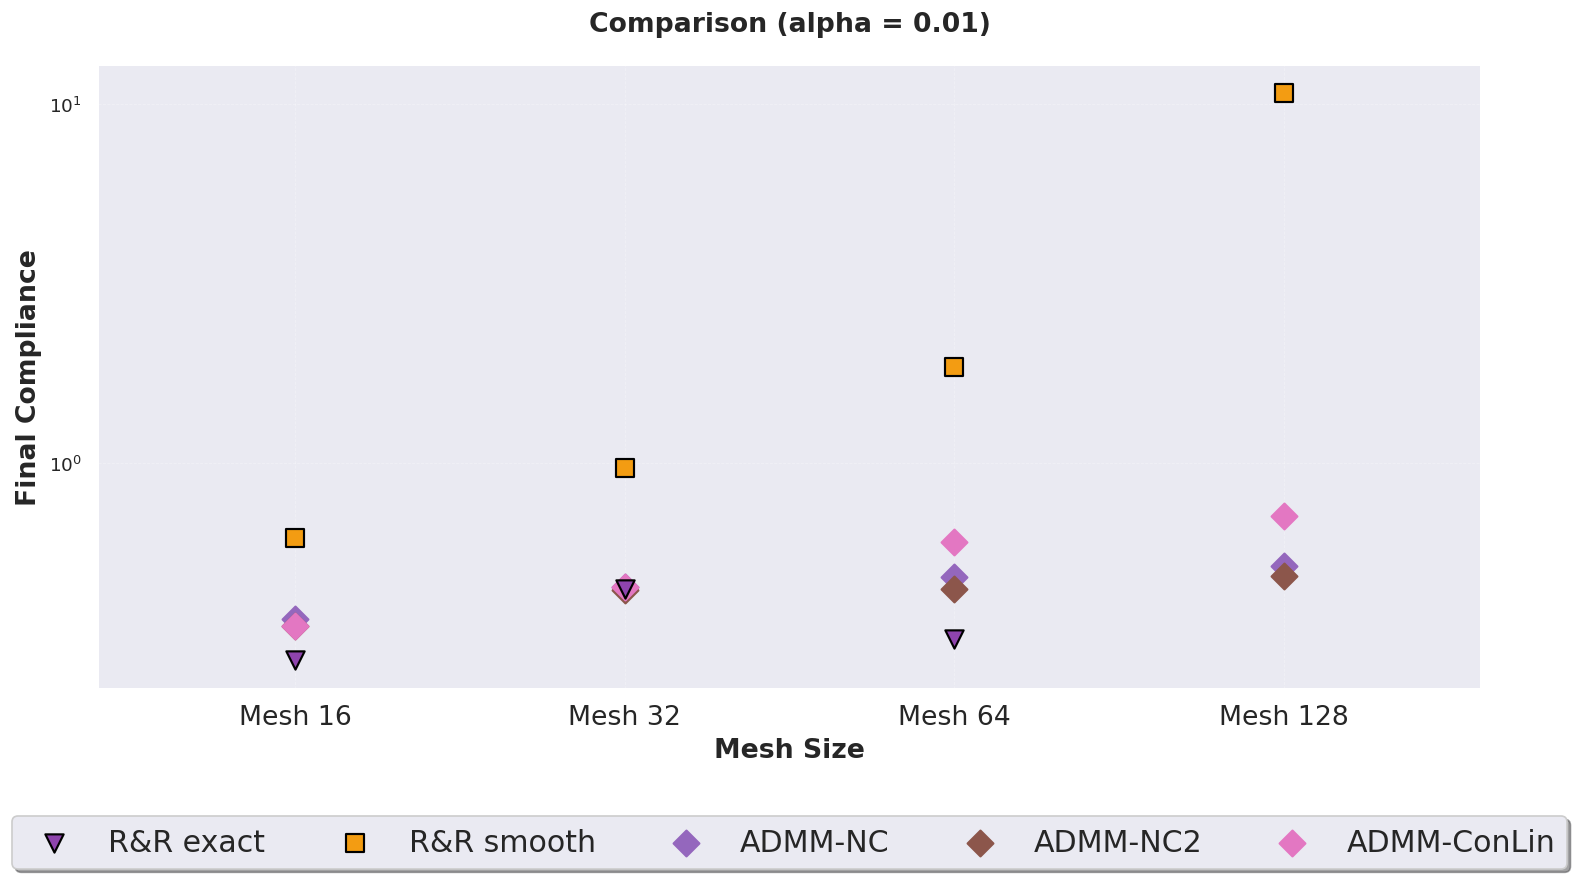


Plot completed for alpha = 0.01


In [24]:
# # Example: Plot for alpha = 1
plot_compliance(alpha=0.01)

## Plot Interpretation

### ADMM Methods (Colored Boxes)
- **Box height**: Shows the interquartile range (IQR) from 25th to 75th percentile
- **Horizontal black line**: Indicates the median (50th percentile)
- **Three different colors**: Represent the three ADMM variants
  - Blue: Standard ADMM
  - Red: ADMM with Distributed TV
  - Green: ADMM with Switching

### Deterministic Methods (Markers)
- **Purple triangles**: FEM method
  - Upward triangle (△): Continuous objective
  - Downward triangle (▽): Discrete objective
- **Orange squares**: FEniCS method (discrete objective)

### Notes
- If data is missing for a particular method/mesh combination, it will be skipped
- Error messages will be printed if files are not found
- The legend is positioned below the plot to avoid interfering with the data

In [18]:
def get_admm_final_tv(alpha, dim, base_dir, suffix="", infeas_threshold=100):
    """
    Get final TV values for ADMM across all seeds, but ONLY include seeds
    whose final infeasibility (last entry of infeas_list) is < infeas_threshold.

    Returns:
        np.ndarray of filtered final TV values, or None if file missing or no valid seeds.
    """
    try:
        print(f"Loading ADMM data from {base_dir} with suffix '{suffix}' for alpha={alpha}, dim={dim}...")
        base = f"{base_dir}_{suffix}" if suffix else base_dir
        h5_path = os.path.join(base, str(alpha), f"{dim}.h5")

        if not os.path.exists(h5_path):
            return None

        tv_values = []
        with h5py.File(h5_path, 'r') as h5f:
            for key in h5f.keys():
                if not key.startswith('seed_'):
                    continue

                grp = h5f[key]

                # Need both lists
                if ('tv_list' not in grp) or ('infeas_list' not in grp):
                    continue

                tv_list = grp['tv_list'][:]
                infeas_list = grp['infeas_list'][:]

                if len(tv_list) == 0 or len(infeas_list) == 0:
                    continue

                final_tv = float(tv_list[-1]*dim/alpha)
                final_infeas = float(infeas_list[-1])
                print(f"Seed {key}: final_tv={final_tv}, final_infeas={final_infeas}")

                # Filter rule
                if final_infeas < infeas_threshold:
                    tv_values.append(final_tv)

        return np.array(tv_values) if tv_values else None

    except Exception as e:
        print(f"Error loading ADMM data for {base_dir}, alpha={alpha}, dim={dim}: {e}")
        return None


def get_fem_tv(alpha, n):
    """
    Get FEM continuous and discrete TV values.
    Returns (cont_tv, disc_tv) or (None, None) if file doesn't exist.
    """
    try:
        fm = femModel(alpha=alpha, n=n, base_dir='relax_and_round_exact/fem_model_tri')
        return fm.tv, fm.tv_cont
    except Exception as e:
        print(f"Error loading FEM data for alpha={alpha}, n={n}: {e}")
        return None, None

def get_admm_gpy_tv(obj, alpha, dim, base_dir='admm_gpy/run_data_admm_gurobi', suffix="method", infeas_threshold=100):
    """
    Get final TV values for ADMM with Gurobi across all seeds.
    Returns np.ndarray of TV values or None if file doesn't exist.
    """
    try:
        #agpy = obj(alpha=alpha, dim=dim, base_dir=base_dir)
        #return fm.compliance + 1/n * (alpha*fm.tv)
        return (obj.trial(0).series.tv[-1]*dim)/alpha
    except Exception as e:
        print(f"Error loading ", str(suffix) ,f" data for alpha={alpha}, n={dim}: {e}")
        return None

    except Exception as e:
        print(f"Error loading ", str(suffix) ,f" data for {base_dir}, alpha={alpha}, dim={dim}: {e}")
        return None

def get_fenics_tv2(alpha, n, seed=0):
    import networkx as nx
    import math
    from relax_and_round_smooth.fenicsviz import fenicsModel
    
    fm = fenicsModel(alpha=alpha, n=n, seed=seed, base_dir='relax_and_round_smooth/fenics_model_tri')
    control = fm.control.vector().get_local()
    def compute_TV(a, b, lam, rho, graph, scale, alpha):
        """Total variation term at (a,b,lam,rho)"""
        # note: lam, rho arent used here  but signature stays same
        diffs = []
        for (u, v), s in zip(graph.edges(), scale):
            diffs.append(s * abs(a[u] - a[v]))
        Gg = sum(diffs)
        # return (1.0 / math.sqrt(len(a)/2)) * Gg * self.alpha
        return Gg
    
    def build_graph(n_x, n_y):
        N = n_x * n_y
        graph = nx.Graph()
        graph.add_nodes_from(range(N))

        for k in range(0, N, 2):
            if k + 1 < N:
                graph.add_edge(k, k + 1)
            if (k + 2) % n_y != 0 and k + 3 < N:
                graph.add_edge(k, k + 3)
            if (k // n_y) != 0:
                nb = k - (n_y - 1)
                if nb >= 0:
                    graph.add_edge(k, nb)

        return graph
    graph = build_graph(n, 2*n)

    scale = np.zeros(len(graph.edges()))
    for k, (u, v) in enumerate(graph.edges()):
        scale[k] = math.sqrt(2) if abs(int(u) - int(v)) == 1 else 1.0

    tv = compute_TV(control, control, None, None, graph, scale, alpha)
    return tv


def get_fenics_tv(alpha, n, seed=0):
    """
    Get FEniCS discrete TV.
    Returns TV or None if file doesn't exist.
    """
    try:
        fm = fenicsModel(alpha=alpha, n=n, seed=seed, base_dir='relax_and_round_smooth/fenics_model_tri')
        #return fm.compliance + 1/n * (alpha*fm.tv)
        return fm.tv * n/alpha
    except Exception as e:
        print(f"Error loading FEniCS data for alpha={alpha}, n={n}: {e}")
        return None


def compute_quantiles(data, quantiles=[0.25, 0.5, 0.75]):
    """
    Compute quantiles from data array.
    Returns dict with quantile values.
    """
    if data is None or len(data) == 0:
        return None
    return {q: np.quantile(data, q) for q in quantiles}

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

def plot_tv(alpha, mesh_sizes=[16, 32, 64, 128], figsize=(14, 8)):
    """
    Create comparison plot for a given alpha value.
    """

    admm_methods_ms = [
        # {'name': 'ADMM-NC', 'base_dir': 'admm_no_simp/run_data_admm_periodic_mergesplit', 'suffix': '', 'color': '#2ecc71'},
        # {'name': 'ADMM-C', 'base_dir': 'admm/run_data_admm_periodic_mergesplit', 'suffix': '',  'color': '#3498db'},
        # {'name': 'ADMM-NC2', 'base_dir': 'admm_distributed_tv/run_data_admm_periodic_mergesplit', 'suffix': '', 'color': '#e74c3c'},
        # {'name': 'ADMM-ConLin', 'base_dir': 'admm_colin/run_data_admm_periodic_mergesplit', 'suffix': '', 'color': "#ccbc2e"}
        #{'name': 'ADMM-4', 'base_dir': 'admm_distributed_tv_no_simp/run_data_admm_dist_tv_mergesplit', 'suffix': '', 'color': '#9b59b6'}
    ]

    admm_methods_gpy = [
        #{'name': 'ADMM-1(lin)', 'base_dir': 'admm_no_simp/run_data_admm_mergesplit', 'suffix': '', 'color': '#2ecc71'},
        {'name': 'ADMM-NC', 'base_dir': 'admm1/run_data_admm_gurobi_great', 'suffix': '',  'color': '#3498db'},
        {'name': 'ADMM-NC2', 'base_dir': 'admm2/run_data_admm_gurobi', 'suffix': '', 'color': '#069494'},
        {'name': 'ADMM-ConLin', 'base_dir': 'admm_colin/run_data_admm_gurobi_great', 'suffix': '', 'color': "#e74c3c"}
        #{'name': 'ADMM-4', 'base_dir': 'admm_distributed_tv_no_simp/run_data_admm_dist_tv_mergesplit', 'suffix': '', 'color': '#9b59b6'}
    ]


    fig, ax = plt.subplots(figsize=figsize)

    x_positions = np.arange(len(mesh_sizes))
    x_labels = [f'Mesh {m}' for m in mesh_sizes]

    # Thinner boxes + clearer separation
    box_width = 0.10         # thinner IQR boxes
    method_spacing = 0.16    # separation between method centers

    handles, labels = [], []
    median_data = {m['name']: [] for m in admm_methods_ms}
    outliers = {}
    # ---- ADMM quantile boxes ----
    for method_idx, method in enumerate(admm_methods_ms):
        print(f"\nProcessing {method['name']}...")
        
        outliers.setdefault(method["name"], {})              # dict per method
        for mesh_idx, mesh_size in enumerate(mesh_sizes):
            # inside your ADMM loop, replace the call with:
            tv = get_admm_final_tv(
                alpha=alpha,
                dim=mesh_size,
                base_dir=method['base_dir'],
                suffix=method['suffix'],
                infeas_threshold=mesh_size
            )

            if tv is None or len(tv) == 0:
                print(f"  Mesh {mesh_size}: No valid seeds after infeasibility filter (infeas < {mesh_size}).")
                continue

            tv = np.asarray(tv, dtype=float)

            # For log scale: filter non-positive values
            pos = tv > 0
            if not np.all(pos):
                bad = np.sum(~pos)
                print(f"  Mesh {mesh_size}: WARNING {bad}/{len(tv)} tv <= 0 (cannot plot on log y). Filtering them out.")
                tv = tv[pos]

            if len(tv) == 0:
                print(f"  Mesh {mesh_size}: All tvs were <= 0 after filtering; skipping.")
                continue

            q25, q50, q75 = np.percentile(tv, [25, 50, 75])

            iqr = q75 - q25
            low_fence  = q25 - 1.5 * iqr
            high_fence = q75 + 1.5 * iqr

            # whisker endpoints (most extreme non-outlier points)
            inlier = (tv >= low_fence) & (tv <= high_fence)
            low_whisk  = tv[inlier].min()
            high_whisk = tv[inlier].max()

            # Centers at [-1, 0, +1] * method_spacing
            offset = (method_idx - 1) * method_spacing
            x_center = x_positions[mesh_idx] + offset

            median_data[method['name']].append((x_center, q50))

            rect = Rectangle(
                (x_center - box_width/2, q25),
                box_width,
                max(q75 - q25, 1e-300),  # avoid zero-height boxes
                facecolor=method['color'],
                alpha=0.55,
                edgecolor=method['color'],
                linewidth=1.8,
                zorder=5
            )
            ax.add_patch(rect)

            # median line
            ax.plot(
                [x_center - box_width/2, x_center + box_width/2],
                [q50, q50],
                color='black',
                linewidth=2.2,
                zorder=6
            )

            ax.plot([x_center, x_center], [low_whisk, q25], color=method['color'], linewidth=1.8, zorder=4)
            ax.plot([x_center, x_center], [q75, high_whisk], color=method['color'], linewidth=1.8, zorder=4)

            # whisker caps
            cap = box_width * 0.8
            ax.plot([x_center - cap/2, x_center + cap/2], [low_whisk, low_whisk], color=method['color'], linewidth=1.8, zorder=4)
            ax.plot([x_center - cap/2, x_center + cap/2], [high_whisk, high_whisk], color=method['color'], linewidth=1.8, zorder=4)
            
            # outliers as points (jittered)
            out = ~inlier
            if np.any(out):
                jitter = (np.random.rand(out.sum()) - 0.5) * box_width * 0.6
                ax.scatter(x_center + jitter, tv[out], s=18, marker='o',
                        color=method['color'], edgecolors='black', linewidths=0.4,
                        alpha=0.9, zorder=7)
            
            outliers[method['name']][mesh_size] = np.where(out)[0]

            print(f"  Mesh {mesh_size}: {len(tv)} seeds (plotted), q25={q25:.6g}, median={q50:.6g}, q75={q75:.6g}")

        handles.append(Patch(facecolor=method['color'], alpha=0.55, edgecolor=method['color'], linewidth=1.8))
        labels.append(method['name'])

    # ---- FEM markers ----
    print("\nProcessing FEM (Relax and Round)...")
    fem_tv, fem_cont_tv, fem_x_positions = [], [], []

    for mesh_idx, mesh_size in enumerate(mesh_sizes):
        tv, tv_cont = get_fem_tv(alpha=alpha, n=mesh_size)
        if tv is not None and tv_cont is not None:
            fem_tv.append(tv)
            fem_cont_tv.append(tv_cont)
            fem_x_positions.append(x_positions[mesh_idx])
            print(f"  Mesh {mesh_size}: fem={tv:.6g}")
        else:
            print(f"  Mesh {mesh_size}: No data")

    if fem_cont_tv:
        # ax.scatter(fem_x_positions, fem_cont_tv, marker='^', s=120,
        #            color='#9b59b6', edgecolors='black', linewidths=1.3,
        #            label='FEM (continuous)', zorder=10)
        ax.scatter(fem_x_positions, fem_tv, marker='v', s=120,
                   color='#8e44ad', edgecolors='black', linewidths=1.3,
                   label='R&R exact', zorder=10)

    # ---- FEniCS markers ----
    print("\nProcessing FEniCS (SIMP Adjoint)...")
    fenics_tv, fenics_x_positions = [], []

    for mesh_idx, mesh_size in enumerate(mesh_sizes):
        tv = get_fenics_tv2(alpha=alpha, n=mesh_size)
        if tv is not None:
            fenics_tv.append(tv)
            fenics_x_positions.append(x_positions[mesh_idx])
            print(f"  Mesh {mesh_size}: tv={tv:.6g}")
        else:
            print(f"  Mesh {mesh_size}: No data")

    if fenics_tv:
        ax.scatter(fenics_x_positions, fenics_tv, marker='s', s=120,
                   color='#f39c12', edgecolors='black', linewidths=1.3,
                   label='R&R smooth', zorder=10)
        
    # ---- ADMM GPY markers ----
    print("\nProcessing ADMM Gurobi...")
    
    for method_idx, method in enumerate(admm_methods_gpy):
        print(f"\nProcessing {method['name']} (Gurobi)...")
        agpy_tv, agpy_x_positions = [], []

        name = method["name"]
        outliers.setdefault(name, {})

        for mesh_idx, mesh_size in enumerate(mesh_sizes):
            try:
                if name == 'ADMM-ConLin':
                    admm_gpy = ADMMColin(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                elif name == 'ADMM-NC':
                    admm_gpy = ADMM(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                elif name == 'ADMM-NC2':
                    admm_gpy = ADMM2(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                # elif name == 'ADMM-1(lin)':
                #     admm_gpy = ADMMNoSIMP(alpha=alpha, dim=mesh_size, base_dir=method['base_dir'])
                else:
                    admm_gpy = None
                
                if admm_gpy is not None:
                    tv = admm_gpy.tv*mesh_size/alpha
                else:
                    tv = None
            except Exception as e:
                print(f"Error loading {name} data for alpha={alpha}, n={mesh_size}: {e}")
                tv = None

            if tv is not None:
                agpy_tv.append(tv)
                agpy_x_positions.append(x_positions[mesh_idx])
                print(f"  Mesh {mesh_size}: tv={tv:.6g}")
            else:
                print(f"  Mesh {mesh_size}: No data")

        if agpy_tv:
            ax.scatter(agpy_x_positions, agpy_tv, marker='D', s=120,
                    color=method['color'], edgecolors=method['color'], linewidths=1.3,
                    label=method['name'], zorder=5)

    # ---- formatting ----
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=16)

    ax.set_xlabel('Mesh Size', fontsize=16, fontweight='bold')
    ax.set_ylabel('Final TV', fontsize=16, fontweight='bold')
    ax.set_title(f'Comparison (α = {alpha})',
                 fontsize=16, fontweight='bold', pad=20)

    ax.set_yscale('log')  # <-- log y-scale

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)

    # give a bit of horizontal margin so offset boxes never clip
    ax.set_xlim(-0.6, len(mesh_sizes) - 0.4)

    admm_handles = handles
    admm_labels = labels

    auto_handles, auto_labels = ax.get_legend_handles_labels()

    # combine (avoid duplicates just in case)
    all_handles = admm_handles + auto_handles
    all_labels  = admm_labels  + auto_labels

    ax.legend(all_handles, all_labels,
            loc='upper center', bbox_to_anchor=(0.5, -0.12),
            ncol=10, fontsize=18, frameon=True, shadow=True)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*60}")
    print(f"Plot completed for alpha = {alpha}")
    print(f"{'='*60}")



Processing FEM (Relax and Round)...
  Mesh 16: fem=73.3137
  Mesh 32: fem=104.243
  Mesh 64: fem=219.142
Error loading FEM data for alpha=0.1, n=128: File not found: relax_and_round_exact/fem_model_tri/0.1/128.h5
  Mesh 128: No data

Processing FEniCS (SIMP Adjoint)...
  Mesh 16: tv=40
  Mesh 32: tv=73.4142
  Mesh 64: tv=187.598
  Mesh 128: tv=298.728

Processing ADMM Gurobi...

Processing ADMM-NC (Gurobi)...
  Mesh 16: tv=53.7372
  Mesh 32: tv=93.9981
  Mesh 64: tv=187.868
  Mesh 128: tv=361.078

Processing ADMM-NC2 (Gurobi)...
  Mesh 16: tv=23.5826
  Mesh 32: tv=35.9928
  Mesh 64: tv=46.7878
  Mesh 128: tv=84.3204

Processing ADMM-ConLin (Gurobi)...
  Mesh 16: tv=36.7423
  Mesh 32: tv=55.8025
  Mesh 64: tv=114.945
  Mesh 128: tv=227.146


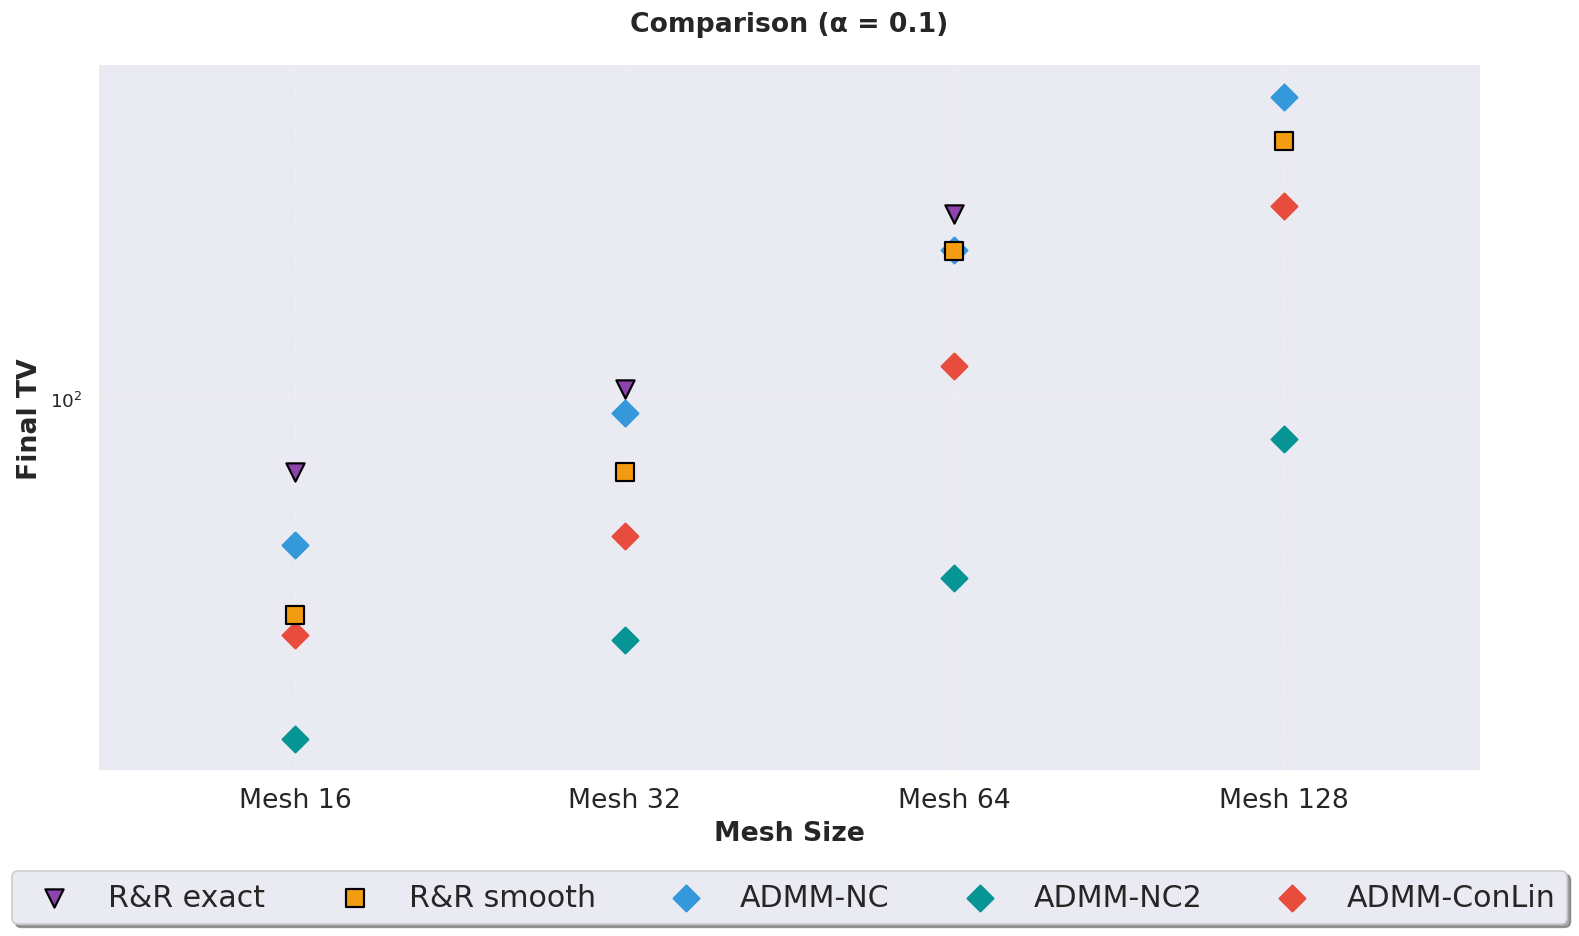


Plot completed for alpha = 0.1


In [21]:
# # Example: Plot for alpha = 1
plot_tv(alpha=0.1)

### ADMM Gpy

In [11]:
admm_gpy = ADMMGpy(alpha=1.0, dim=64, base_dir="admm_gpy/run_data_admm_gurobi")

FileNotFoundError: H5 file not found: admm_gpy/run_data_admm_gurobi/1.0/64.h5

In [8]:
print("best Obj:", admm_gpy.objective_best)
print("best TV:", admm_gpy.tv_best)
print("best compliance:", admm_gpy.compliance_best)

print("median Obj:", admm_gpy.objective)
print("median TV:", admm_gpy.tv)
print("median compliance:", admm_gpy.compliance)

best Obj: 2.177411748414495
best TV: 872.0
best compliance: 0.8149117484144951
median Obj: 2.177411748414495
median TV: 872.0
median compliance: 0.8149117484144951


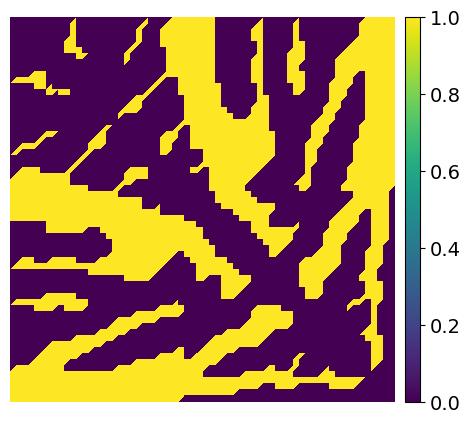

In [10]:
admm_gpy.plot_control(best=True, cont=True)

### ADMM Diststributed TV linear

In [20]:
admm_dist_tv_no_simp = ADMMDistTVNoSIMP(alpha=1.0, dim=64, base_dir="admm_distributed_tv_no_simp/run_data_admm_dist_tv_mergesplit")

In [21]:
print("median Obj:", admm_dist_tv_no_simp.objective)
print("median TV:", admm_dist_tv_no_simp.tv)
print("median compliance:", admm_dist_tv_no_simp.compliance)

print("best Obj:", admm_dist_tv_no_simp.objective_best)
print("best TV:", admm_dist_tv_no_simp.tv_best)
print("best compliance:", admm_dist_tv_no_simp.compliance_best)

median Obj: 43.406725583299014
median TV: 71.24264068711929
median compliance: 42.29355932256278
best Obj: 13.801477769988509
best TV: 99.62741699796949
best compliance: 12.244799379395236


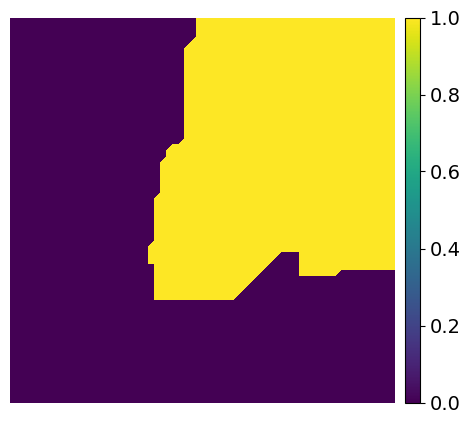

In [23]:
admm_dist_tv_no_simp.plot_control(best=True)

### ADMM (linear)

In [79]:
admm_no_simp = ADMMNoSIMP(alpha=1.0, dim=64, base_dir="admm_no_simp/run_data_admm_mergesplit")

In [80]:
print("median Obj:", admm_no_simp.objective)
print("median TV:", admm_no_simp.tv)
print("median compliance:", admm_no_simp.compliance)

print("best Obj:", admm_no_simp.objective_best)
print("best TV:", admm_no_simp.tv_best)
print("best compliance:", admm_no_simp.compliance_best)

median Obj: 3.8009328950240824
median TV: 0.0
median compliance: 3.8009328950240824
best Obj: 3.8009328950240824
best TV: 0.0
best compliance: 3.8009328950240824


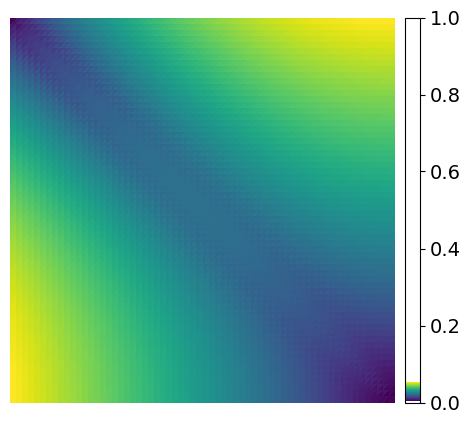

In [81]:
admm_no_simp.plot_control(best=True, cont=True)

#### ADMM Distributed TV

In [9]:
admm_dist = ADMMDistTV(alpha=1.0, dim=64, base_dir="admm_distributed_tv/run_data_admm_dist_tv_mergesplit")

In [10]:
print("best Obj:", admm_dist.objective_best)
print("best TV:", admm_dist.tv_best)
print("best compliance:", admm_dist.compliance_best)

print("median Obj:", admm_dist.objective)
print("median TV:", admm_dist.tv)
print("median compliance:", admm_dist.compliance)

best Obj: 8.015792337767639
best TV: 340.43860018001294
best compliance: 2.6964392099549377
median Obj: 8.338223704502571
median TV: 306.1248916810281
median compliance: 3.5550222719865063


In [11]:
admm_dist.seeds()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [12]:
admm_dist.trial(6).series.runtime_sub1

array([7.31624111, 5.12127659, 6.5381493 , 5.70569167, 5.74474873,
       5.32313575, 5.57442035, 5.42769721, 5.48166915, 6.32816338,
       6.25992385, 6.07988086, 5.85292619, 6.22302311, 5.90934062,
       6.04497866, 6.34863333, 6.63134639, 6.36395878, 6.21475215,
       5.6472448 , 6.17413016, 5.46363603, 6.20291009, 5.32574654,
       6.87237652, 5.49187908, 6.5859683 , 5.31907721, 6.09736397])

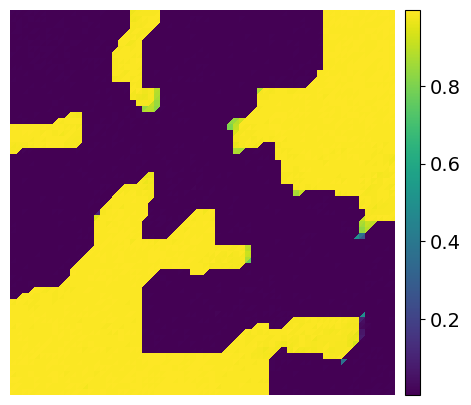

In [14]:
admm_dist.plot_control(best=True, cont=True)

### ADMM (SIMP)

In [15]:
admm = ADMM(alpha=1.0, dim=64, base_dir="admm/run_data_admm_mergesplit")

In [16]:
print("best Obj:", admm.objective_best)
print("best TV:", admm.tv_best)
print("best compliance:", admm.compliance_best)

print("median Obj:", admm.objective)
print("median TV:", admm.tv)
print("median compliance:", admm.compliance)

best Obj: 8.656504561155709
best TV: 334.1248916810282
best compliance: 3.435803128639643
median Obj: 10.65988671679454
median TV: 499.13708498984823
median compliance: 2.860869763828162


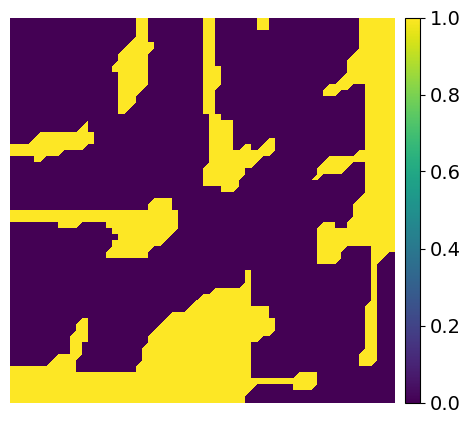

In [18]:
admm.plot_control()

### Relax and Round Exact TV (FEM)

In [53]:
fem = femModel(alpha=1.0, n=64, base_dir='relax_and_round_exact/fem_model_tri')

In [54]:
print("best Obj:", fem.objective)
print("best TV:", fem.tv)
print("best compliance:", fem.compliance)

print("median Obj:", fem.objective)
print("median TV:", fem.tv)
print("median compliance:", fem.compliance)

best Obj: 5.994436193121464
best TV: 25.2892135623731
best compliance: 2.8332844978248266
median Obj: 5.994436193121464
median TV: 25.2892135623731
median compliance: 2.8332844978248266


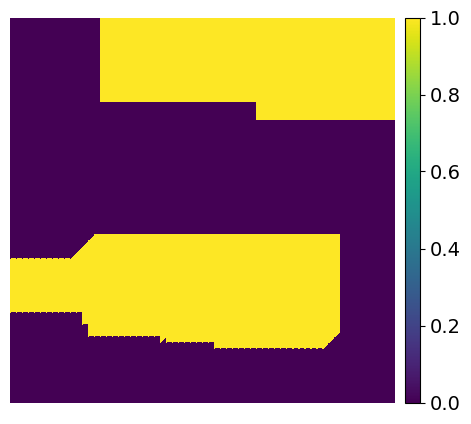

In [ ]:
fem.plot_control()

### Relax and Round Smooth TV

In [56]:
fenics = fenicsModel(alpha=1.0, n=64, base_dir='relax_and_round_smooth/fenics_model_tri')

In [57]:
print("best Obj:", fenics.objective)
print("best TV:", fenics.tv)
print("best compliance:", fenics.compliance)

print("median Obj:", fenics.objective)
print("median TV:", fenics.tv)
print("median compliance:", fenics.compliance)

best Obj: 19.23902547569433
best TV: 178.29794958200748
best compliance: 16.453120013475463
median Obj: 19.23902547569433
median TV: 178.29794958200748
median compliance: 16.453120013475463


In [ ]:
fenics.metadata["runtime_total"]

{'dim': 64, 'alpha': 1.0, 'V_frac': 0.4, 'runtime_total': 421.0703448820859}

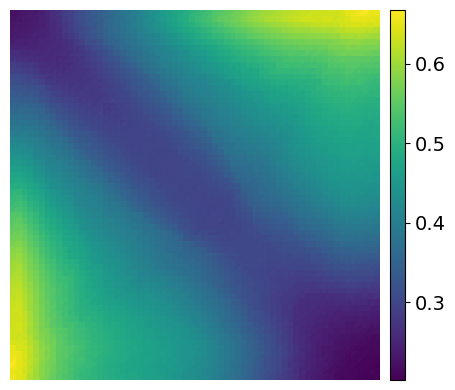

In [50]:
fenics.plot_control(cont=True)

In [76]:
print(admm_dist.median_seed)
print(admm_dist.best_seed)

17
11


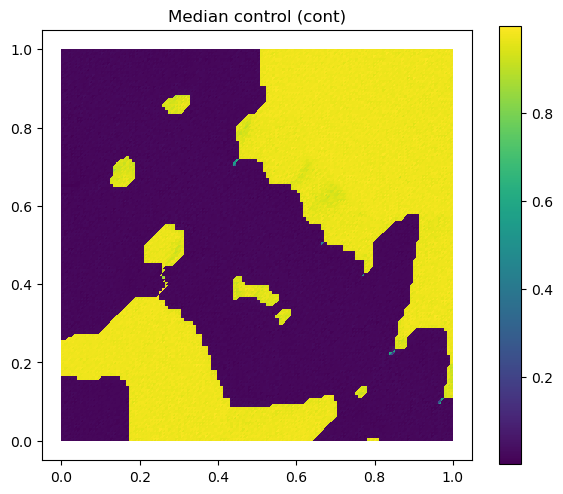

In [78]:
x = admm_dist.plot_control(cont=True)

In [23]:
from fenics import *

In [24]:
c_list = admm_dist.trial(8).iters.control

NameError: name 'admm_dist' is not defined

In [108]:
dim = int(np.sqrt(c_list.shape[1]//2))
mesh = UnitSquareMesh(dim, dim)
Vc = FunctionSpace(mesh, "DG", 0)
a = Function(Vc)

In [ ]:
fig, ax = plt.subplots((c_list.shape[0])//7 + (1 if (c_list.shape[0])%7 else 0), 7, figsize=(15, 8))
for i in range(c_list.shape[0]):
    r, c = i//7, i%7
    a.vector().set_local(c_list[i])
    plt.sca(ax[r,c])
    ax[r,c].clear()
    plot(a)
plt.tight_layout()
plt.show()

In [131]:
print("Median Runtime sub1:",np.median(admm_dist.trial(29).series.runtime_sub1))
print("Median Runtime sub2:",np.median(admm_dist.trial(29).series.runtime_sub2))

Median Runtime sub1: 37.3503572170157
Median Runtime sub2: 0.22229711944237351


### ADMM regular

In [25]:
admm = ADMM(alpha=0.1, dim=32, base_dir="admm/run_data_admm_mergesplit")

In [26]:
admm.objective_best

2.0628848598225726

In [27]:
print(admm.median_seed)
print(admm.best_seed)

19
14


In [1]:
admm.control_best

NameError: name 'admm' is not defined

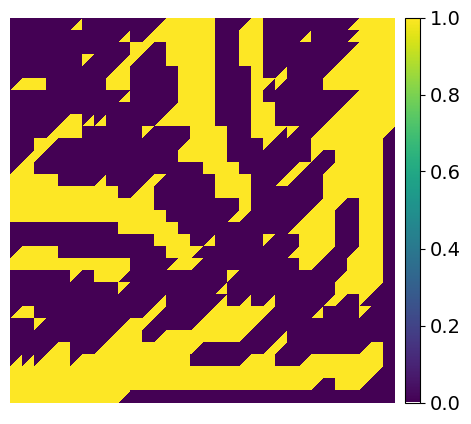

In [28]:
x = admm.plot_control(cont=True)

In [69]:
c_list = admm_no_simp.trial(15).iters.control_cont

In [70]:
admm_no_simp.trial(15).series.objective[-1]

3.628389650665663

In [71]:
dim = int(np.sqrt(c_list.shape[1]//2))
mesh = UnitSquareMesh(dim, dim)
Vc = FunctionSpace(mesh, "DG", 0)
a = Function(Vc)

In [72]:
# outliers["ADMM"][64]

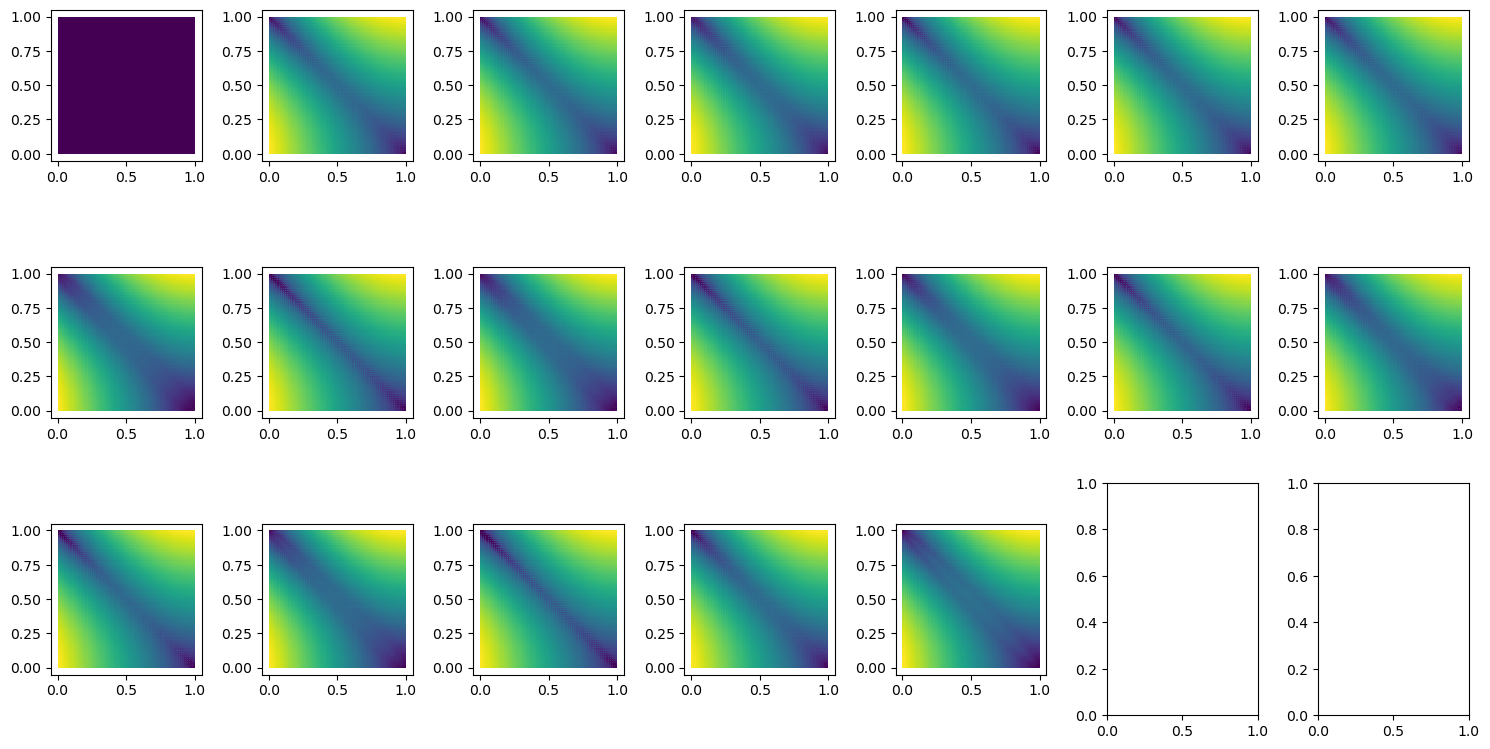

In [73]:
fig, ax = plt.subplots((c_list.shape[0])//7 + (1 if (c_list.shape[0])%7 else 0), 7, figsize=(15, 8))
for i in range(c_list.shape[0]):
    r, c = i//7, i%7
    a.vector().set_local(c_list[i])
    plt.sca(ax[r,c])
    ax[r,c].clear()
    plot(a)
plt.tight_layout()
plt.show()

In [130]:
print("Median Runtime sub1:",np.median(admm_dist.trial(20).series.runtime_sub1))
print("Median Runtime sub2:",np.median(admm_dist.trial(20).series.runtime_sub2))

Median Runtime sub1: 37.70268874801695
Median Runtime sub2: 0.2566207154886797


In [17]:
gradL = admm.trial(6).iters.control[0]

In [29]:
fem = femModel(alpha=0.1, n=16, base_dir="relax_and_round/fem_model_tri")

In [1]:
fem.plot_control(cont=False)

NameError: name 'fem' is not defined

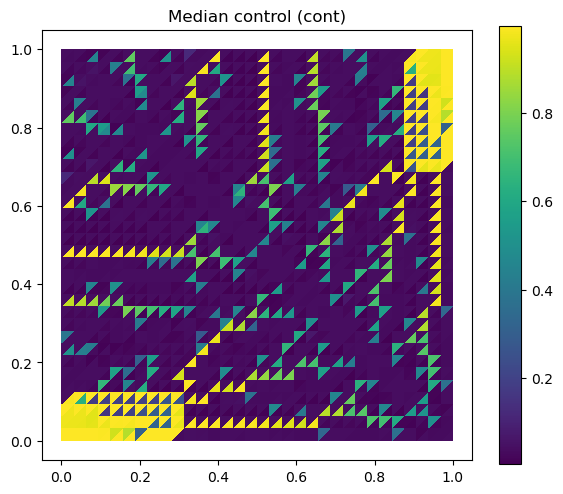

In [17]:
admm.plot_control(cont=True)

In [6]:
import math

# -------------------- formatting helpers --------------------
# def fmt_num(x, sci_threshold=1e-3, nd=2):
#     if x is None:
#         return "--"
#     try:
#         x = float(x)
#     except Exception:
#         return "--"

#     if x == 0:
#         return "0"

#     ax = abs(x)

#     if ax < sci_threshold or ax >= 1e4:
#         exp = int(math.floor(math.log10(ax)))
#         mant = x / (10**exp)
#         return rf"{mant:.{nd}g}\times10^{{{exp}}}"

#     return f"{x:.{nd}g}"

def fmt_num(x, nd=1):
    if x is None:
        return "--"
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return "--"

def fmt_tv(x):
    if x is None:
        return "--"
    try:
        return f"{float(x):.1f}"
    except Exception:
        return "--"


def cell_MB(median, best, is_tv=False):

    if median is None or best is None:
        return "--"

    if is_tv:
        return rf"$M:{fmt_tv(median)}$\quad$B:{fmt_tv(best)}$"

    return rf"$M:{fmt_num(median)}$\quad$B:{fmt_num(best)}$"


def cell_single(val, is_tv=False):

    if val is None:
        return "--"

    if is_tv:
        return rf"${fmt_tv(val)}$"

    return rf"${fmt_num(val)}$"


def mesh_label(n):
    return rf"${n} \times {n}$"


# -------------------- runtime placeholder --------------------
def get_runtime_placeholder(model_obj):
    """
    Returns a runtime string for the LaTeX table.

    ADMM-style:
      sum_i [ sum(runtime_sub1) + sum(runtime_sub2) ] over all seeds i

    R&R-style:
      model_obj.metadata["runtime_total"]
    """
    if model_obj is None:
        return "-"

    # ---------- R&R: metadata["runtime_total"] ----------
    md = safe_get(model_obj, "metadata")
    if isinstance(md, dict) and ("runtime_total" in md) and (md["runtime_total"] is not None):
        try:
            return f"{float(md['runtime_total']):.1f}"
        except Exception:
            pass

    # ---------- ADMM: sum over trials/seeds of runtime_sub1 + runtime_sub2 ----------
    # robustly get number of trials from seeds()
    n_trials = None
    try:
        n_trials = len(model_obj.seeds())
        #print(f"Got number of trials from seeds(): {n_trials}")
    except Exception:
        # fallback if seeds is a list/attr instead of a method
        try:
            n_trials = len(model_obj.seeds)
        except Exception:
            n_trials = None

    if n_trials is None:
        return "-"

    total = 0.0
    got_any = False

    for i in range(n_trials):
        #print(f"Processing trial {i} for runtime...")
        try:
            tr = model_obj.trial(i)
            #print(f"  Trial {i}: got trial object: {tr}")
            ser = tr.series
            #print(f"  Trial {i}: got series object: {ser}")

            sub1 = sum(getattr(ser, "runtime_sub1", []))
            sub2 = sum(getattr(ser, "runtime_sub2", []))
            #print(f"Trial {i}: runtime_sub1={sub1}, runtime_sub2={sub2}")

            total += sub1 + sub2
            got_any = True
        except Exception:
            #print(f"Something corrupted in trial {i}, skipping runtime for this trial.")
            # skip trial i if anything is missing/corrupt
            continue

    if not got_any:
        #print("No valid runtime data found across all trials.")
        return "-"

    return f"{total:.1f}"


# -------------------- safe attribute getter --------------------
def safe_get(obj, name):
    try:
        return getattr(obj, name)
    except Exception:
        return None


# -------------------- extractors --------------------
def extract_admm(model_obj):

    if model_obj is None:
        return {"obj": "--", "comp": "--", "tv": "--", "rt": "-"}

    return {
        "obj": cell_MB(
            safe_get(model_obj, "objective"),
            safe_get(model_obj, "objective_best"),
        ),

        "comp": cell_MB(
            safe_get(model_obj, "compliance"),
            safe_get(model_obj, "compliance_best"),
        ),

        #  TV
        "tv": cell_MB(
            safe_get(model_obj, "tv"),
            safe_get(model_obj, "tv_best"),
            is_tv=True,
        ),

        "rt": get_runtime_placeholder(model_obj),
    }


def extract_rr(model_obj):

    if model_obj is None:
        return {"obj": "--", "comp": "--", "tv": "--", "rt": "-"}

    return {
        "obj": cell_single(safe_get(model_obj, "objective")),
        "comp": cell_single(safe_get(model_obj, "compliance")),

        # TV: fixed format
        "tv": cell_single(safe_get(model_obj, "tv"), is_tv=True),

        "rt": get_runtime_placeholder(model_obj),
    }


# -------------------- safe constructor --------------------
def safe_build(ctor, mesh):
    try:
        return ctor(mesh)
    except Exception as e:
        print(f"[WARN] Failed for mesh {mesh}: {e}")
        return None


# -------------------- method registry --------------------
def make_methods(alpha):

    return [
        {
            "name": "ADMM-1(SIMP)",
            "ctor": lambda m: ADMM(
                alpha=alpha, dim=m,
                base_dir="admm/run_data_admm_mergesplit"
            ),
            "extract": extract_admm,
        },
        {
            "name": "ADMM-2(SIMP)",
            "ctor": lambda m: ADMMDistTV(
                alpha=alpha, dim=m,
                base_dir="admm_distributed_tv/run_data_admm_dist_tv_mergesplit"
            ),
            "extract": extract_admm,
        },
        {
            "name": "ADMM-1(lin)",
            "ctor": lambda m: ADMMNoSIMP(
                alpha=alpha, dim=m,
                base_dir="admm_no_simp/run_data_admm_mergesplit"
            ),
            "extract": extract_admm,
        },
        {
            "name": "ADMM-2(lin)",
            "ctor": lambda m: ADMMDistTVNoSIMP(
                alpha=alpha, dim=m,
                base_dir="admm_distributed_tv_no_simp/run_data_admm_dist_tv_mergesplit"
            ),
            "extract": extract_admm,
        },
        {
            "name": r"R\&R-smooth",
            "ctor": lambda m: fenicsModel(
                alpha=alpha, n=m,
                base_dir="relax_and_round_smooth/fenics_model_tri"
            ),
            "extract": extract_rr,
        },
        {
            "name": r"R\&R-exact",
            "ctor": lambda m: femModel(
                alpha=alpha, n=m,
                base_dir="relax_and_round_exact/fem_model_tri"
            ),
            "extract": extract_rr,
        },
    ]


# -------------------- latex generator --------------------
def latex_table_body(alpha=1e-2, mesh_sizes=(16, 32, 64, 128)):

    methods = make_methods(alpha)
    n_methods = len(methods)

    lines = []

    for m in mesh_sizes:

        lines.append(f"% ---------- {m}x{m} ----------")
        lines.append(
            rf"\multirow{{{n_methods}}}{{*}}{{{mesh_label(m)}}}"
        )

        for j, method in enumerate(methods):

            # safe build
            obj = safe_build(method["ctor"], m)

            # safe extract
            cells = method["extract"](obj)

            mesh_col = "" if j == 0 else ""

            row = rf" {mesh_col} & {method['name']} & {cells['obj']} & {cells['comp']} & {cells['tv']} & {cells['rt']} \\"

            lines.append(row)

        lines.append(r"\midrule")
        lines.append("")

    return "\n".join(lines)


# -------------------- usage --------------------
# print(latex_table_body(alpha=1e-2, mesh_sizes=(16,32,64,128)))


In [7]:
print(latex_table_body(alpha=1.0, mesh_sizes=(16, 32, 64, 128, 265)))

[WARN] Failed for mesh 128: "H5 file has no 'summary' group. Did you create it after runs?"
[WARN] Failed for mesh 128: File not found: relax_and_round_exact/fem_model_tri/1.0/128.h5
[WARN] Failed for mesh 265: H5 file not found: admm/run_data_admm_mergesplit/1.0/265.h5
[WARN] Failed for mesh 265: H5 file not found: admm_distributed_tv/run_data_admm_dist_tv_mergesplit/1.0/265.h5
[WARN] Failed for mesh 265: H5 file not found: admm_no_simp/run_data_admm_mergesplit/1.0/265.h5
[WARN] Failed for mesh 265: H5 file not found: admm_distributed_tv_no_simp/run_data_admm_dist_tv_mergesplit/1.0/265.h5
[WARN] Failed for mesh 265: File not found: relax_and_round_smooth/fenics_model_tri/1.0/265.h5
[WARN] Failed for mesh 265: File not found: relax_and_round_exact/fem_model_tri/1.0/265.h5
% ---------- 16x16 ----------
\multirow{6}{*}{$16 \times 16$}
  & ADMM-1(SIMP) & $M:9.2$\quad$B:7.9$ & $M:3.6$\quad$B:3.1$ & $M:89.5$\quad$B:77.5$ & 516.8 \\
  & ADMM-2(SIMP) & $M:7.7$\quad$B:7.4$ & $M:3.3$\quad$B:3.2

In [ ]:
# import networkx as nx

# def _build_graph(mesh):
#         G = nx.Graph()
#         num_cells = mesh.num_cells()
#         G.add_nodes_from(range(num_cells))

#         # get the connectivity: cell → facets → neighboring cells
#         mesh.init(2, 1)
#         mesh.init(1, 2)

#         for cell in cells(mesh):
#             cid = cell.index()
#             for facet in facets(cell):
#                 for neighbor in facet.entities(2):
#                     if neighbor != cid:
#                         G.add_edge(cid, neighbor)

#         return G

In [ ]:
# mesh = UnitSquareMesh(2, 2)
# G = _build_graph(mesh)
# print(G.edges())

[(0, 3), (0, 1), (1, 4), (2, 3), (3, 6), (4, 7), (4, 5), (6, 7)]


In [33]:
admm = ADMM(alpha=0.1, dim=32, base_dir="admm/test_run_data_admm_mergesplit")

In [34]:
import networkx as nx
from fenics import *
import math

In [35]:
print(admm.best_seed)
print(admm.median_seed)

8
0


In [43]:
control = admm.control
#tv_iter = admm.trial(2).series.tv
admm.tv
admm.objective
#print("TV iter:", tv_iter)

2.4007462734262743

In [38]:
def _build_graph(mesh):
        G = nx.Graph()
        num_cells = mesh.num_cells()
        G.add_nodes_from(range(num_cells))

        # get the connectivity: cell → facets → neighboring cells
        mesh.init(2, 1)
        mesh.init(1, 2)

        for cell in cells(mesh):
            cid = cell.index()
            for facet in facets(cell):
                for neighbor in facet.entities(2):
                    if neighbor != cid:
                        G.add_edge(cid, neighbor)

        return G

def compute_TV(a, b, lam, rho, graph, scale):
        """Total variation term at (a,b,lam,rho)"""
        # note: lam, rho arent used here  but signature stays same
        diffs = []
        for (u, v), s in zip(graph.edges(), scale):
            diffs.append(s * abs(a[u] - a[v]))
        Gg = sum(diffs)
        return Gg

In [40]:
G = _build_graph(UnitSquareMesh(32, 32))

scale = np.zeros(len(G.edges()))
for k, (u, v) in enumerate(G.edges()):
    scale[k] = math.sqrt(2) if abs(u - v) == 1 else 1.0

tv = compute_TV(control, None, None, None, G, scale)
print("TV:", tv)

TV: 503.178715550191


In [16]:
admm = ADMMColin(alpha=1e-1, dim=64, base_dir='admm_colin/run_data_admm_gurobi')
seed = admm.best_seed
trial = admm.trial(seed)

# Sum all runtimes across all iterations
runtime_sub1_list = trial.series.runtime_sub1
runtime_sub2_list = trial.series.runtime_sub2

In [22]:
admm = ADMM(alpha=1e-1, dim=64, base_dir='admm_distributed_tv/run_data_admm_dist_tv_gurobi')
seed = admm.best_seed
trial = admm.trial(seed)

# Sum all runtimes across all iterations
runtime_sub1_list = trial.series.runtime_sub1
runtime_sub2_list = trial.series.runtime_sub2

In [23]:
print(runtime_sub1_list)
print(runtime_sub2_list)

[10.97639696  5.89085517 11.84231348  6.26740166 11.80406648 10.6386876
 14.59947092  6.15839437 11.89697096  9.21080773 16.29867389  8.20282345
  7.79315449 12.65196479  7.08697323 12.67747642 17.93893381  7.4466507
  7.91222342 19.92995884]
[17.73206919 18.71772619 19.13564558 19.5563921  28.05332147 25.3884178
 18.95105522 19.9090963  18.92557639 23.12930001 22.83023845 19.46237768
 20.50875159 19.03357118 20.13680961 35.43944852 35.54257416 36.82073978
 37.56404573 36.85698628]


In [20]:
fm = fenicsModel(alpha=1e-1, n=64, seed=seed, base_dir='relax_and_round_smooth/fenics_model_tri')
runtime = fm.metadata.get('runtime_total')
print(runtime)

114.38241351000033


## Runtime Comparison Plots

In [21]:
def get_admm_runtime_data(alpha, dim, base_dir, suffix=''):
    """
    Get runtime data for ADMM algorithms (sum of all iterations).
    Returns (runtime_sub1, runtime_sub2, total_runtime) or (None, None, None) if unavailable.
    """
    try:
        if suffix:
            admm = ADMM(alpha=alpha, dim=dim, base_dir=base_dir, suffix=suffix)
        else:
            admm = ADMM(alpha=alpha, dim=dim, base_dir=base_dir)
        
        seed = admm.median_seed
        trial = admm.trial(seed)
        num_seeds = len(admm.seeds())
        
        # Sum all runtimes across all iterations
        runtime_sub1_list = trial.series.runtime_sub1
        runtime_sub2_list = trial.series.runtime_sub2
        
        runtime_sub1_total = num_seeds * float(np.sum(runtime_sub1_list))
        runtime_sub2_total = num_seeds * float(np.sum(runtime_sub2_list))
        total_runtime = runtime_sub1_total + runtime_sub2_total
        
        return runtime_sub1_total, runtime_sub2_total, total_runtime
    except Exception as e:
        print(f"Error loading ADMM runtime data for alpha={alpha}, dim={dim}: {e}")
        return None, None, None


def get_admm_colin_runtime_data(alpha, dim, use_best=False):
    """
    Get runtime data for ADMM Colin algorithm (sum of all iterations).
    Returns (runtime_sub1, runtime_sub2, total_runtime) or (None, None, None) if unavailable.
    """
    try:
        admm = ADMMColin(alpha=alpha, dim=dim, base_dir='admm_colin/run_data_admm_periodic_gurobi')
        seed = admm.best_seed if use_best else admm.median_seed
        trial = admm.trial(seed)

        num_seeds = len(admm.seeds())
        
        # Sum all runtimes across all iterations
        runtime_sub1_list = trial.series.runtime_sub1
        runtime_sub2_list = trial.series.runtime_sub2
        
        runtime_sub1_total = num_seeds * float(np.sum(runtime_sub1_list))
        runtime_sub2_total = num_seeds * float(np.sum(runtime_sub2_list))
        total_runtime = runtime_sub1_total + runtime_sub2_total
        
        return runtime_sub1_total, runtime_sub2_total, total_runtime
    except Exception as e:
        print(f"Error loading ADMM Colin runtime data for alpha={alpha}, dim={dim}: {e}")
        return None, None, None


def get_fem_runtime_data(alpha, n):
    """
    Get total runtime for FEM model.
    Returns runtime_total or None if unavailable.
    """
    try:
        fm = femModel(alpha=alpha, n=n, base_dir='relax_and_round_exact/fem_model_tri')
        runtime = fm.metadata.get('runtime_total')
        return float(runtime) if runtime is not None else None
    except Exception as e:
        print(f"Error loading FEM runtime data for alpha={alpha}, n={n}: {e}")
        return None


def get_fenics_runtime_data(alpha, n, seed=0):
    """
    Get total runtime for FEniCS model.
    Returns runtime_total or None if unavailable.
    """
    try:
        fm = fenicsModel(alpha=alpha, n=n, seed=seed, base_dir='relax_and_round_smooth/fenics_model_tri')
        runtime = fm.metadata.get('runtime_total')
        return float(runtime) if runtime is not None else None
    except Exception as e:
        print(f"Error loading FEniCS runtime data for alpha={alpha}, n={n}: {e}")
        return None


Error loading ADMM runtime data for alpha=0.01, dim=128: H5 file not found: admm_no_simp/run_data_admm_gurobi/0.01/128.h5
Error loading FEM runtime data for alpha=0.01, n=128: File not found: relax_and_round_exact/fem_model_tri/0.01/128.h5


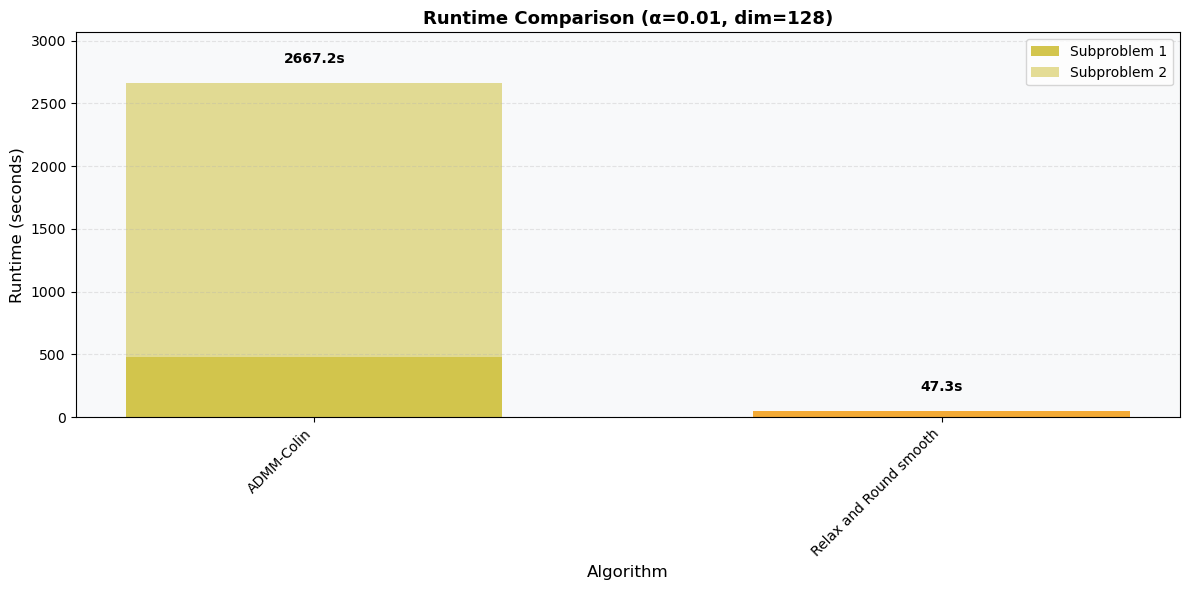

In [23]:
def plot_runtime_comparison(alpha, dim=64, figsize=(12, 6)):
    """
    Create stacked bar plot comparing runtime breakdown across all algorithms.
    Each bar is divided into two colors (shades):
    - Bottom (darker, alpha=0.85): runtime_sub1
    - Top (lighter, alpha=0.5): runtime_sub2
    Same color per algorithm but different transparency for each subproblem.
    
    For ADMM algorithms: shows sub1 and sub2 breakdown
    For FEM and FEniCS: shows single bar (no subproblem breakdown)
    """
    
    algorithms = [
        ('ADMM-1', 'admm1/run_data_admm_periodic_gurobi', '', 'admm1'),
        ('ADMM-2', 'admm2/run_data_admm_periodic_gurobi', '', 'admm2'),
        #('ADMM-GPy', 'admm_gpy/run_data_admm_gurobi', '', 'admm_gpy'),
        ('ADMM-Lin', 'admm_no_simp/run_data_admm_gurobi', '', 'admm_lin'),
        ('ADMM-Colin', 'admm_colin/run_data_admm_gurobi', '', 'admm_colin'),
        ('Relax and Round exact', 'relax_and_round_exact/fem_model_tri', '-', 'fem'),
        ('Relax and Round smooth', 'relax_and_round_smooth/fenics_model_tri', '-', 'fenics'),
    ]
    
    # Color palette for each algorithm
    colors = {
        'admm1': '#3498db',      # blue
        'admm2': '#e74c3c',         # purple
        'admm_gpy': '#F18F01',             # orange
        'admm_colin': '#ccbc2e',           # dark red
        'fem': '#8e44ad',                  # teal
        'admm_lin': '#2ecc71',             # mauve
        'fenics': '#f39c12',               # crimson
    }
    
    fig, ax = plt.subplots(figsize=figsize)
    
    x_positions = []
    sub1_runtime_vals = []
    sub2_runtime_vals = []
    labels = []
    bar_colors = []
    
    bar_width = 0.6
    x_pos = 0
    
    for algo_name, base_dir, suffix, algo_type in algorithms:
        sub1, sub2, total = None, None, None
        
        if algo_type == 'admm':
            sub1, sub2, total = get_admm_runtime_data(alpha, dim, base_dir, suffix)
            
        elif algo_type == 'admm_dist_tv':
            sub1, sub2, total = get_admm_runtime_data(alpha, dim, base_dir, suffix)
                
        # elif algo_type == 'admm_gpy':
        #     sub1, sub2, total = get_admm_runtime_data(alpha, dim, base_dir, suffix)
        elif algo_type == 'admm_lin':
            sub1, sub2, total = get_admm_runtime_data(alpha, dim, base_dir, suffix)
                
        elif algo_type == 'admm_colin':
            sub1, sub2, total = get_admm_colin_runtime_data(alpha, dim)
                
        elif algo_type == 'fem':
            # For FEM, show single bar (no subproblem breakdown)
            fem_runtime = get_fem_runtime_data(alpha, dim)
            if fem_runtime is not None:
                sub1 = fem_runtime
                sub2 = 0
                total = fem_runtime
                
        elif algo_type == 'fenics':
            # For FEniCS, show single bar (no subproblem breakdown)
            fenics_runtime = get_fenics_runtime_data(alpha, dim, seed=0)
            if fenics_runtime is not None:
                sub1 = fenics_runtime
                sub2 = 0
                total = fenics_runtime
        
        # Add to lists if we have valid data
        if total is not None and sub1 is not None and sub2 is not None:
            x_positions.append(x_pos)
            sub1_runtime_vals.append(sub1)
            sub2_runtime_vals.append(sub2)
            labels.append(algo_name)
            bar_colors.append(colors[algo_type])
            x_pos += 1
    
    # Plot stacked bars
    if x_positions:
        # Plot sub1 (darker, bottom part)
        bars1 = ax.bar(x_positions, sub1_runtime_vals, bar_width, 
                      color=bar_colors, alpha=0.85, label='Subproblem 1')
        
        # Plot sub2 (lighter, top part, stacked on sub1)
        bars2 = ax.bar(x_positions, sub2_runtime_vals, bar_width, 
                      bottom=sub1_runtime_vals, color=bar_colors, alpha=0.5, label='Subproblem 2')
        
        ax.set_xlabel('Algorithm', fontsize=12)
        ax.set_ylabel('Runtime (seconds)', fontsize=12)
        ax.set_title(f'Runtime Comparison (α={alpha}, dim={dim})', fontsize=13, fontweight='bold')
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_facecolor('#f8f9fa')
        ax.legend(loc='upper right', fontsize=10)
        
        # Add total value labels on top of stacked bars
        max_total = max([s1 + s2 for s1, s2 in zip(sub1_runtime_vals, sub2_runtime_vals)])
        for x_pos, s1, s2 in zip(x_positions, sub1_runtime_vals, sub2_runtime_vals):
            total_time = s1 + s2
            ax.text(x_pos, total_time + max_total*0.05, f'{total_time:.1f}s', 
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Add margin above the plot to prevent cutoff
        #ax.set_ylim(0, max_total * 1.15)
    plt.ylim(top=max_total * 1.15)
    plt.tight_layout()
    #plt.yscale('symlog')
    plt.show()


# Generate runtime plot for a specific alpha
# Example: plot_runtime_comparison(alpha=1e-5, dim=32)
try:
    plot_runtime_comparison(alpha=0.01, dim=128)

except Exception as e:
    traceback.print_exc()
    print(f"Error creating runtime plots: {e}")

## Objective Value Comparison Plots

Error loading ADMM objective data for admm, alpha=0.1, dim=64: H5 file not found: admm/run_data_admm_gurobi/0.1/64.h5
Error loading ADMM objective data for admm_tv, alpha=0.1, dim=64: name 'ADMMDistTV' is not defined
Error loading FEM objective data for alpha=0.1, n=64: name 'femModel' is not defined
Error loading FEniCS objective data for alpha=0.1, n=64: name 'fenicsModel' is not defined


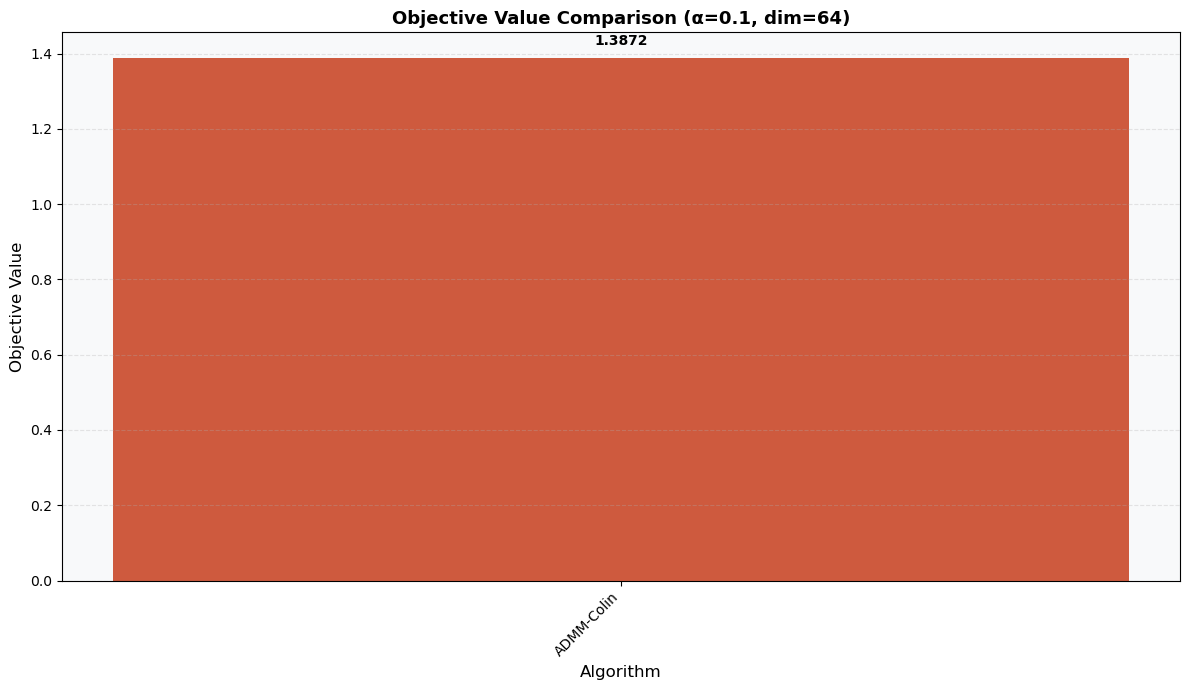

In [ ]:
def get_admm_objective_data(alpha, dim, algo_type='admm'):
    """
    Get objective value from ADMM algorithms (median seed) using gurobi directories.
    Returns objective value or None if unavailable.
    """
    try:
        if algo_type == 'admm':
            admm = ADMM(alpha=alpha, dim=dim, base_dir='admm/run_data_admm_gurobi')
        elif algo_type == 'admm_tv':
            admm = ADMMDistTV(alpha=alpha, dim=dim, base_dir='admm_distributed_tv/run_data_admm_dist_tv_gurobi')
        elif algo_type == 'admm_colin':
            admm = ADMMColin(alpha=alpha, dim=dim, base_dir='admm_colin/run_data_admm_gurobi')
        else:
            return None
        
        return float(admm.objective)
    except Exception as e:
        print(f"Error loading ADMM objective data for {algo_type}, alpha={alpha}, dim={dim}: {e}")
        return None


def get_fem_objective_data(alpha, n):
    """
    Get discrete objective value from FEM model.
    Returns objective value or None if unavailable.
    """
    try:
        fm = femModel(alpha=alpha, n=n, base_dir='relax_and_round_exact/fem_model_tri')
        return float(fm.objective)
    except Exception as e:
        print(f"Error loading FEM objective data for alpha={alpha}, n={n}: {e}")
        return None


def get_fenics_objective_data(alpha, n, seed=0):
    """
    Get discrete objective value from FEniCS model.
    Returns objective value or None if unavailable.
    """
    try:
        fm = fenicsModel(alpha=alpha, n=n, seed=seed, base_dir='relax_and_round_smooth/fenics_model_tri')
        return float(fm.objective)
    except Exception as e:
        print(f"Error loading FEniCS objective data for alpha={alpha}, n={n}: {e}")
        return None


def plot_objective_comparison(alpha, dim=32, figsize=(12, 7)):
    """
    Create comparison plot comparing objective values across all algorithms for a single alpha value.
    """
    if '_set_obj_comp_style' in globals():
        _set_obj_comp_style()
    else:
        import matplotlib as mpl
        base_rc = {
            "figure.dpi": 120,
            "lines.linewidth": 2.8,
            "lines.markersize": 5,
            "font.size": 12,
            "axes.labelsize": 13,
            "axes.titlesize": 14,
            "legend.fontsize": 11,
        }
        try:
            import seaborn as sns
            sns.set_theme(style='darkgrid')
            mpl.rcParams.update(base_rc)
        except Exception:
            mpl.rcParams.update(base_rc)
    
    algorithms = [
        ('ADMM', 'admm'),
        ('ADMM-TV', 'admm_tv'),
        ('ADMM-Colin', 'admm_colin'),
        ('FEM', 'fem'),
        ('FEniCS', 'fenics'),
    ]
    
    cmap = plt.get_cmap('tab10')
    colors = {key: cmap(i % cmap.N) for i, (_, key) in enumerate(algorithms)}
    
    fig, ax = plt.subplots(figsize=figsize)
    
    x_positions = []
    objective_vals = []
    labels = []
    bar_colors = []
    
    bar_width = 0.6
    x_pos = 0
    
    for algo_name, algo_type in algorithms:
        if algo_type == 'fem':
            obj_val = get_fem_objective_data(alpha, dim)
        elif algo_type == 'fenics':
            obj_val = get_fenics_objective_data(alpha, dim, seed=0)
        else:
            obj_val = get_admm_objective_data(alpha, dim, algo_type)
        
        if obj_val is not None:
            x_positions.append(x_pos)
            objective_vals.append(obj_val)
            labels.append(algo_name)
            bar_colors.append(colors[algo_type])
            x_pos += 1
    
    if x_positions:
        ax.bar(x_positions, objective_vals, bar_width, color=bar_colors, alpha=0.9)
        
        ax.set_xlabel('Algorithm')
        ax.set_ylabel('Objective Value')
        ax.set_title(f'Objective Value Comparison (alpha={alpha}, dim={dim})')
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=25, ha='right')
        ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.3, alpha=0.6)
        
        for xpos, obj_val in zip(x_positions, objective_vals):
            ax.text(xpos, obj_val + max(objective_vals) * 0.02, f'{obj_val:.4f}',
                   ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout(rect=(0, 0.02, 1, 1))
    plt.show()


try:
    plot_objective_comparison(alpha=1e-1, dim=64)
except Exception as e:
    print(f"Error creating objective plots: {e}")
    import traceback
    traceback.print_exc()

Error loading ADMM runtime data for alpha=0.1, dim=128: H5 file not found: admm2/run_data_admm_gurobi/0.1/128.h5
Error loading ADMM runtime data for alpha=0.1, dim=16: H5 file not found: admm_no_simp/run_data_admm_gurobi/0.1/16.h5
Error loading ADMM runtime data for alpha=0.1, dim=32: H5 file not found: admm_no_simp/run_data_admm_gurobi/0.1/32.h5
Error loading ADMM runtime data for alpha=0.1, dim=64: H5 file not found: admm_no_simp/run_data_admm_gurobi/0.1/64.h5
Error loading ADMM runtime data for alpha=0.1, dim=128: H5 file not found: admm_no_simp/run_data_admm_gurobi/0.1/128.h5
No runtime data available for ADMM-Lin.
Error loading FEM runtime data for alpha=0.1, n=16: name 'femModel' is not defined
Error loading FEM runtime data for alpha=0.1, n=32: name 'femModel' is not defined
Error loading FEM runtime data for alpha=0.1, n=64: name 'femModel' is not defined
Error loading FEM runtime data for alpha=0.1, n=128: name 'femModel' is not defined
No runtime data available for Relax and 

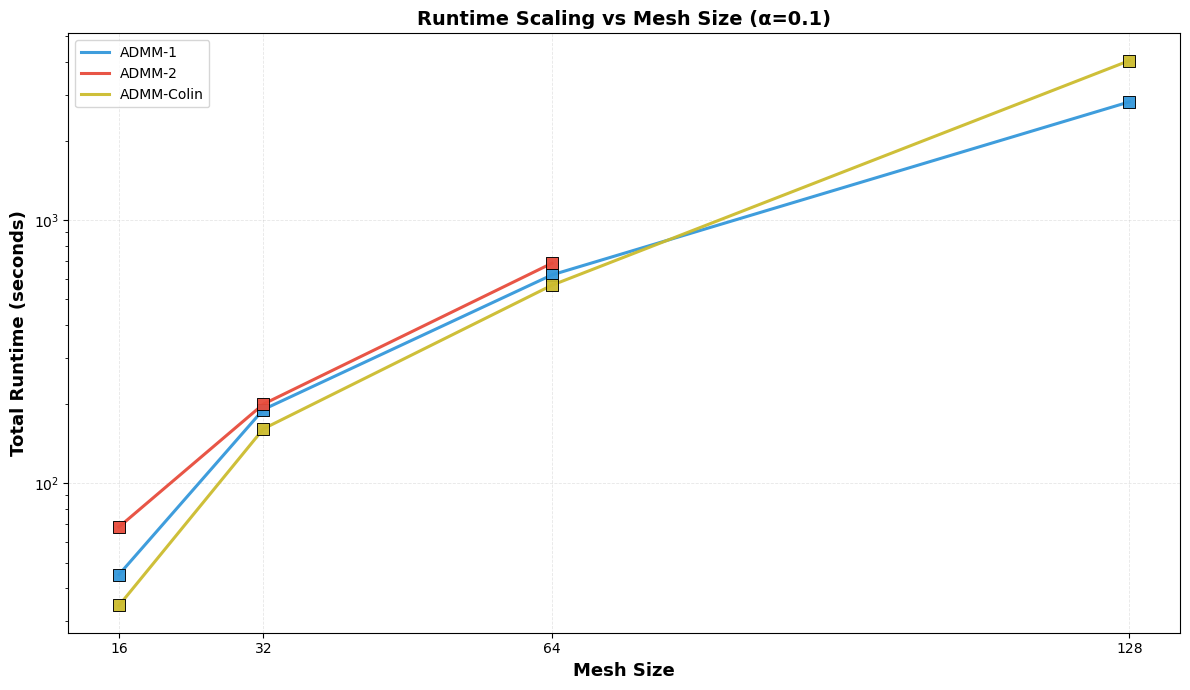

In [92]:
def plot_runtime_scaling(alpha, mesh_sizes=(16, 32, 64, 128), figsize=(12, 7)):
    """
    Plot runtime scaling with mesh size for one alpha across methods.

    For each method:
    - x-axis: mesh sizes
    - y-axis: total runtime (seconds)
    - scatter points for each mesh
    - line connecting points across meshes
    """
    methods = [
        ("ADMM-1", "admm", "admm1/run_data_admm_gurobi", ""),
        ("ADMM-2", "admm_dist_tv", "admm2/run_data_admm_gurobi", ""),
        ("ADMM-Lin", "admm_lin", "admm_no_simp/run_data_admm_gurobi", ""),
        ("ADMM-Colin", "admm_colin", "admm_colin/run_data_admm_gurobi", ""),
        ("Relax and Round exact", "fem", None, None),
        ("Relax and Round smooth", "fenics", None, None),
    ]

    # Keep colors consistent with existing runtime plot.
    colors = {
        "admm": "#3498db",
        "admm_dist_tv": "#e74c3c",
        "admm_gpy": "#F18F01",
        "admm_colin": "#ccbc2e",
        "fem": "#8e44ad",
        "admm_lin": "#2ecc71",
        "fenics": "#f39c12",
    }

    fig, ax = plt.subplots(figsize=figsize)

    for label, method_key, base_dir, suffix in methods:
        x_vals = []
        y_vals = []

        for mesh in mesh_sizes:
            total = None

            if method_key in {"admm", "admm_dist_tv", "admm_lin"}:
                _, _, total = get_admm_runtime_data(alpha, mesh, base_dir, suffix or "")
            elif method_key == "admm_colin":
                _, _, total = get_admm_colin_runtime_data(alpha, mesh)
            elif method_key == "fem":
                total = get_fem_runtime_data(alpha, mesh)
            elif method_key == "fenics":
                total = get_fenics_runtime_data(alpha, mesh, seed=0)

            if total is not None and np.isfinite(total):
                x_vals.append(mesh)
                y_vals.append(float(total))

        if not x_vals:
            print(f"No runtime data available for {label}.")
            continue

        ax.plot(
            x_vals,
            y_vals,
            color=colors[method_key],
            linewidth=2.2,
            alpha=0.95,
            label=label,
            zorder=2,
        )
        ax.scatter(
            x_vals,
            y_vals,
            color=colors[method_key],
            edgecolors="black",
            linewidths=0.7,
            marker='s',
            s=70,
            alpha=0.95,
            zorder=3,
        )

    ax.set_xlabel("Mesh Size", fontsize=13, fontweight="bold")
    ax.set_ylabel("Total Runtime (seconds)", fontsize=13, fontweight="bold")
    ax.set_title(f"Runtime Scaling vs Mesh Size (α={alpha})", fontsize=14, fontweight="bold")

    ax.set_xticks(list(mesh_sizes))
    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.6)
    ax.set_axisbelow(True)

    # Use log scale when all plotted runtimes are positive.
    y_data = []
    for line in ax.get_lines():
        y_data.extend(line.get_ydata())
    if len(y_data) > 0 and np.all(np.asarray(y_data) > 0):
        ax.set_yscale("log")

    ax.legend(loc="upper left", fontsize=10, frameon=True)
    plt.tight_layout()
    plt.show()


# Example call
plot_runtime_scaling(alpha=0.1, mesh_sizes=(16, 32, 64, 128))

In [104]:
# Seed-wise control iterate grids (2x5) for a chosen method and iteration index
from fenics import UnitSquareMesh, FunctionSpace, Function, plot as fenics_plot


def _build_method_object(method_name, alpha, dim):
    """Create the requested method wrapper using its default directory."""
    key = str(method_name).strip().lower()

    registry = {
        "admm-1": lambda: ADMM(alpha=alpha, dim=dim, base_dir="admm1/run_data_admm_mergesplit"),
        "admm-1-gpy": lambda: ADMM(alpha=alpha, dim=dim, base_dir="admm1/run_data_admm_gurobi"),
        "admm-2": lambda: ADMMDistTV(alpha=alpha, dim=dim, base_dir="admm2/run_data_admm_dist_tv_mergesplit"),
        "admm-2-gpy": lambda: ADMM2(alpha=alpha, dim=dim, base_dir="admm2/run_data_admm_gurobi"),
        "admm-lin": lambda: ADMMNoSIMP(alpha=alpha, dim=dim, base_dir="admm_no_simp/run_data_admm_mergesplit"),
        "admm-colin": lambda: ADMMColin(alpha=alpha, dim=dim, base_dir="admm_colin/run_data_admm_mergesplit"),
        "admm-colin-gpy": lambda: ADMMColin(alpha=alpha, dim=dim, base_dir="admm_colin/run_data_admm_gurobi"),
        "admm-lin-gpy": lambda: ADMMNoSIMP(alpha=alpha, dim=dim, base_dir="admm_no_simp/run_data_admm_gurobi"),
    }

    if key not in registry:
        supported = ", ".join(sorted(registry.keys()))
        raise ValueError(f"Unknown method_name='{method_name}'. Supported: {supported}")

    return registry[key]()


def _seed_control_at_iter(method_obj, seed, iter_idx=-1, cont=False):
    """Return control vector for a given seed/iteration.

    Parameters
    ----------
    cont : bool
        If True, use continuous control (b_list / control_cont).
        If False, use discrete control (a_list / control).
    """
    trial = method_obj.trial(seed)
    attr = "control_cont" if cont else "control"
    fallback = "control" if cont else "control_cont"

    controls = None
    for key in (attr, fallback):
        if hasattr(trial.iters, key):
            try:
                arr = np.asarray(getattr(trial.iters, key), dtype=float)
                if arr.ndim == 2 and arr.shape[0] > 0:
                    controls = arr
                    break
            except Exception:
                continue

    if controls is None or controls.ndim != 2 or controls.shape[0] == 0:
        raise ValueError(f"No iterate control array found for seed={seed}")

    k = int(iter_idx)
    if k < 0:
        k = controls.shape[0] - 1
    if k < 0 or k >= controls.shape[0]:
        raise IndexError(f"iter_idx={iter_idx} out of range for seed={seed}; available iters={controls.shape[0]}")

    return controls[k]


def plot_controls_all_seeds(method_name, alpha, dim, iter_idx=-1, ncols=5, nrows=2, cont=False):
    """
    Plot control iterate for all seeds for a method in nrows x ncols pages.

    Parameters
    ----------
    method_name : str
        Method key (e.g. 'admm-1', 'admm-2', 'admm-lin', 'admm-colin').
    alpha : float
    dim : int
    iter_idx : int
        Iterate index. Use -1 for last iterate in each seed.
    ncols, nrows : int
        Grid layout per page. Default is 2 rows x 5 columns.
    cont : bool
        If True, plot continuous control (b_list). If False, plot discrete control (a_list).
    """
    method_obj = _build_method_object(method_name, alpha=alpha, dim=dim)
    seed_list = list(method_obj.seeds())

    if len(seed_list) == 0:
        print("No seeds found for this method/configuration.")
        return

    mesh = UnitSquareMesh(dim, dim)
    Vc = FunctionSpace(mesh, "DG", 0)

    ctrl_label = "continuous" if cont else "discrete"
    page_size = nrows * ncols
    n_pages = (len(seed_list) + page_size - 1) // page_size

    for page in range(n_pages):
        start = page * page_size
        end = min((page + 1) * page_size, len(seed_list))
        page_seeds = seed_list[start:end]

        fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.1 * nrows))
        axes = np.asarray(axes).reshape(nrows, ncols)

        for j in range(page_size):
            r, c = divmod(j, ncols)
            ax = axes[r, c]

            if j >= len(page_seeds):
                ax.set_axis_off()
                continue

            seed = page_seeds[j]
            try:
                control_vec = _seed_control_at_iter(method_obj, seed=seed, iter_idx=iter_idx, cont=cont)

                f = Function(Vc)
                f.vector().set_local(np.asarray(control_vec, dtype=float).ravel())
                f.vector().apply("insert")

                plt.sca(ax)
                ax.clear()
                fenics_plot(f, edgecolor="none")
                ax.set_axis_off()
                ax.set_title(f"seed={seed}", fontsize=10)
            except Exception as e:
                ax.set_axis_off()
                ax.text(0.5, 0.5, f"seed={seed}\nERROR", ha="center", va="center", fontsize=9)
                print(f"Skipping seed={seed}: {e}")

        iter_text = "last" if int(iter_idx) == -1 else str(int(iter_idx))
        fig.suptitle(
            f"{method_name} {ctrl_label} controls at iterate {iter_text} (alpha={alpha}, dim={dim})",
            fontsize=13,
            fontweight="bold",
            y=1.02,
        )
        plt.tight_layout()
        plt.show()


# Example:
# plot_controls_all_seeds(method_name="admm-colin", alpha=0.01, dim=64, iter_idx=-1, cont=False)
# plot_controls_all_seeds(method_name="admm-colin", alpha=0.01, dim=64, iter_idx=-1, cont=True)


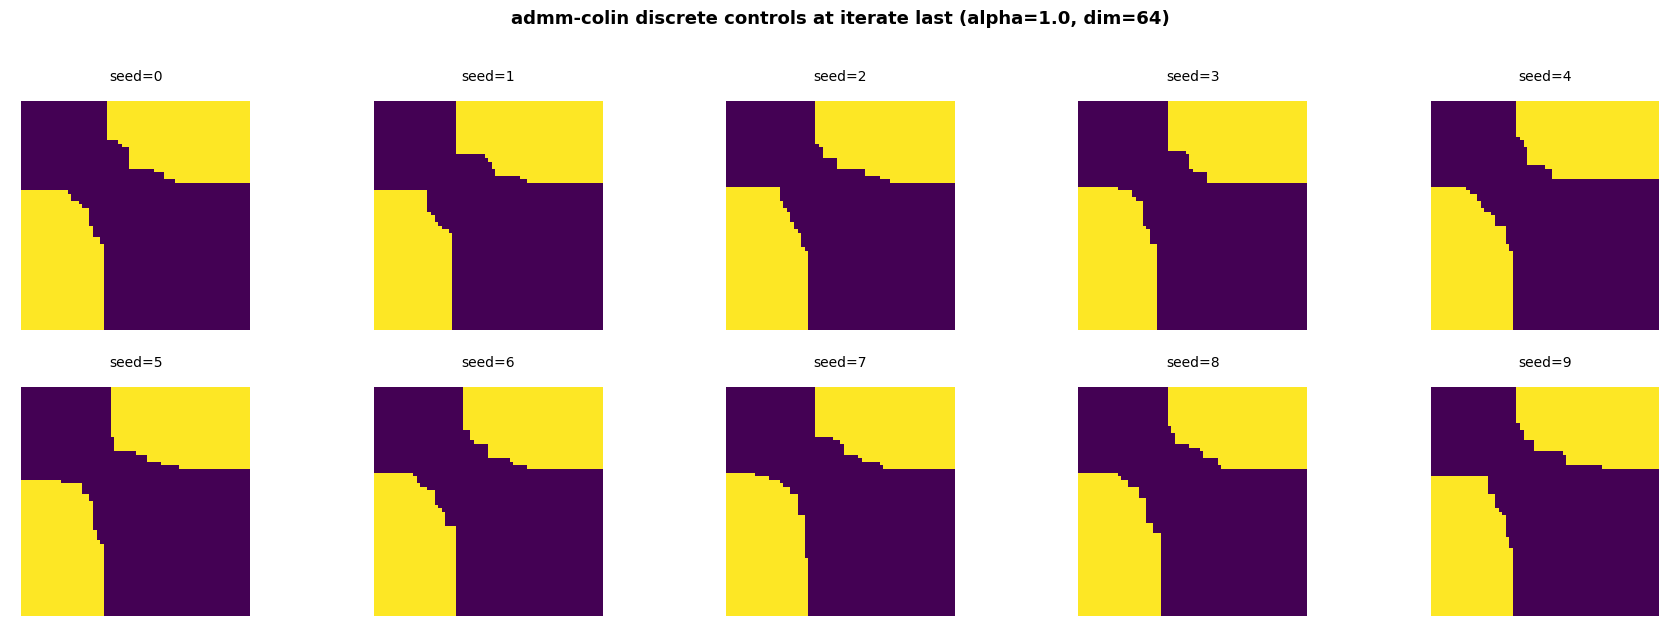

In [41]:
plot_controls_all_seeds(method_name="admm-colin", alpha=1.0, dim=64, iter_idx=-1)

In [148]:
def plot_all_iterates(method_name, alpha, dim, which=1, disc =False, best=False, ncols=5, nrows=4, start_iter=1):
    """
    Plot control iterates for the best or median seed in a single grid.

    Parameters
    ----------
    method_name : str
        Method key (e.g. 'admm-1', 'admm-2', 'admm-lin', 'admm-colin').
    alpha : float
    dim : int
    best : bool
        If True, use the best seed. If False (default), use the median seed.
    cont : bool
        If True, plot continuous control (b_list / control_cont).
        If False (default), plot discrete control (a_list / control).
    ncols, nrows : int
        Grid layout. Default is max 4 rows x 5 columns.
    start_iter : int
        First iterate to plot. Default 1 (starts from control[1]).
    """
    method_obj = _build_method_object(method_name, alpha=alpha, dim=dim)

    if best:
        seed = method_obj.best_seed
        seed_label = f"best seed={seed}"
    else:
        seed = method_obj.median_seed
        seed_label = f"median seed={seed}"

    trial = method_obj.trial(seed)
    if which == 1:
        attr = "control_1"
        fallback = "control_disc"
        ctrl_label = "control 1"
    if which==2:
        attr = "control_2"
        fallback = "control_disc"
        ctrl_label = "control 2"
    if disc:
        attr = "control_disc"
        fallback = "control_disc"
        ctrl_label = "discrete control"

    controls = None
    for key in (attr, fallback):
        if hasattr(trial.iters, key):
            try:
                arr = np.asarray(getattr(trial.iters, key), dtype=float)
                if arr.ndim == 2 and arr.shape[0] > 0:
                    controls = arr
                    break
            except Exception:
                continue

    if controls is None:
        print("No control iterates found.")
        return

    n_iters = controls.shape[0]

    start = max(int(start_iter), 0)
    if start >= n_iters:
        print(f"start_iter={start_iter} out of range; available iterates: 0..{n_iters - 1}")
        return

    max_slots = nrows * ncols
    end = min(start + max_slots, n_iters)
    iter_range = list(range(start, end))

    mesh = UnitSquareMesh(dim, dim)
    Vc = FunctionSpace(mesh, "DG", 0)

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.1 * nrows))
    axes = np.asarray(axes).reshape(nrows, ncols)

    for j in range(max_slots):
        r, c = divmod(j, ncols)
        ax = axes[r, c]

        if j >= len(iter_range):
            ax.set_axis_off()
            continue

        k = iter_range[j]
        try:
            f = Function(Vc)
            f.vector().set_local(np.asarray(controls[k], dtype=float).ravel())
            f.vector().apply("insert")

            plt.sca(ax)
            ax.clear()
            fenics_plot(f, edgecolor="none")
            ax.set_axis_off()
            ax.set_title(f"iter={k}", fontsize=10)
        except Exception as e:
            ax.set_axis_off()
            ax.text(0.5, 0.5, f"iter={k}\nERROR", ha="center", va="center", fontsize=9)
            print(f"Skipping iter={k}: {e}")

    if end < n_iters:
        print(f"Showing iterates {start}..{end - 1} out of 0..{n_iters - 1} (increase grid or change start_iter).")

    fig.suptitle(
        f"{method_name} {ctrl_label} controls — {seed_label} (alpha={alpha}, dim={dim})",
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


# Example:
# plot_all_iterates(method_name="admm-colin", alpha=1.0, dim=64, best=True, cont=False, start_iter=1)
# plot_all_iterates(method_name="admm-1", alpha=1.0, dim=64, best=True, cont=True, start_iter=1)


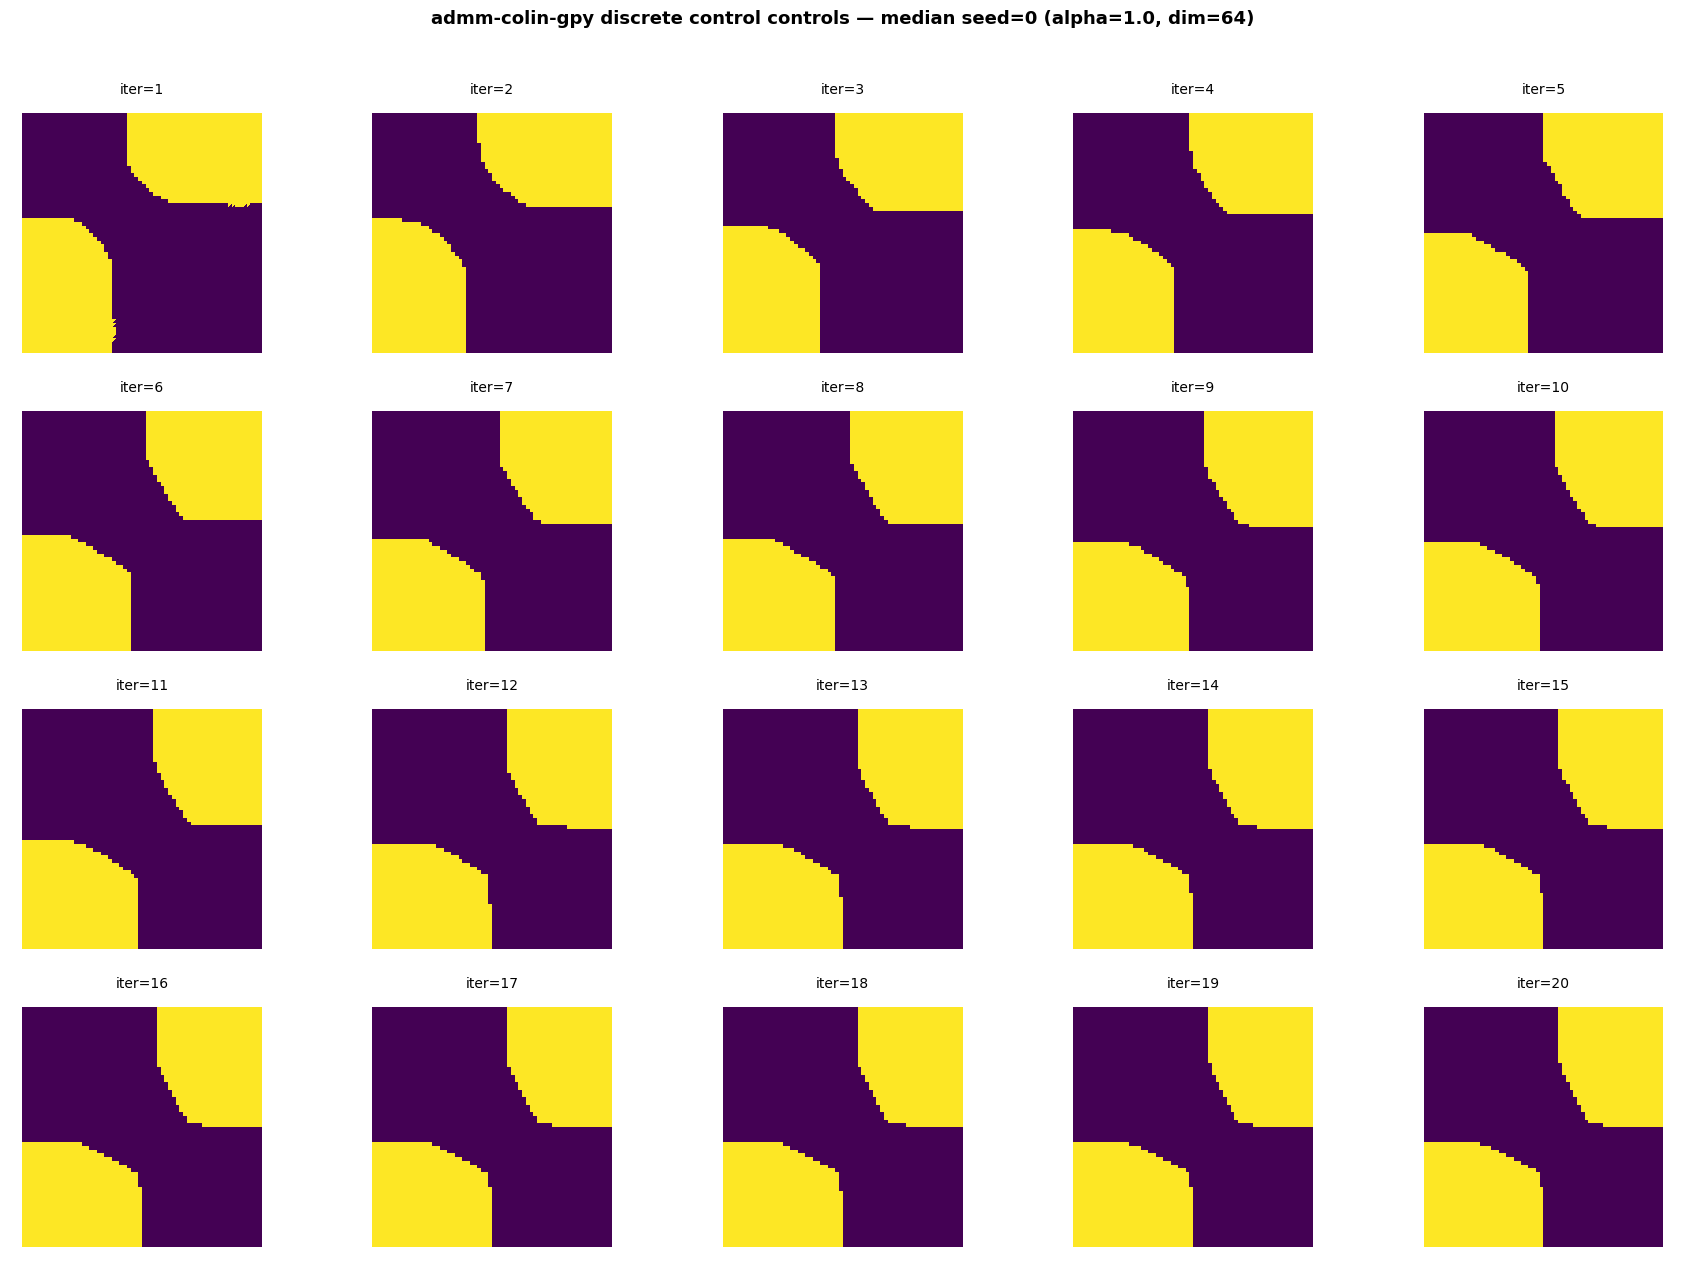

In [150]:
plot_all_iterates(method_name="admm-colin-gpy", alpha=1.0, dim=64, disc=True, which=1, start_iter=1)

In [122]:
# ADMMColin-specific helpers: OC objective F(b^k) and OC gradient grids
import numpy as np
import matplotlib.pyplot as plt
from admmcolinviz import _plot_control_tripcolor, _transpose_control_triangles

def plot_colin_oc_F(admm_colin, trial_idx, oc_iter_idx=None,
                    ax=None, figsize=(7, 4), color="#1f77b4"):

    oc_iters = admm_colin.trial(trial_idx).iters.oc_iters

    if len(oc_iters) == 0:
        raise ValueError(f"No OC iterations found for trial {trial_idx}.")

    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if oc_iter_idx is None:
        y = []
        x = np.arange(len(oc_iters))
        for oc in oc_iters:
            f_arr = np.asarray(oc.F, dtype=float).ravel()
            y.append(float(f_arr[-1]) if f_arr.size > 0 else np.nan)

        y = np.asarray(y, dtype=float)
        valid = np.isfinite(y)

        ax.plot(x[valid], y[valid], color=color, linewidth=2.2,
                marker="o", markersize=4)

        ax.set_title(f"Trial {trial_idx}", fontsize=12, fontweight="bold")
        ax.set_xlabel("OC iteration", fontsize=10)

    else:
        f_arr = np.asarray(oc_iters[oc_iter_idx].F, dtype=float).ravel()
        x = np.arange(f_arr.size)

        if f_arr.size == 1:
            ax.scatter(x, f_arr, color=color, s=40)
        else:
            ax.plot(x, f_arr, color=color, linewidth=2.2,
                    marker="o", markersize=4)

        ax.set_title(f"OC iter {oc_iter_idx}", fontsize=12)
        ax.set_xlabel("OC iter (k)", fontsize=10)

    ax.set_ylabel(r"$F(b^{k})$", fontsize=10)
    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
    ax.set_axisbelow(True)

    return ax 


def plot_colin_oc_gradients_grid(
    admm_colin,
    trial_idx,
    oc_iter_idx,
    grad_start=0,
    grad_end=None,
    ncols=8,
    cmap="viridis",
    fix_diagonal_reflection=True,
    panel_size=(1.9, 1.9),
    title_fontsize=7,
    show_colorbar=True,
    colorbar_label=r"$\nabla_v^k F(v^k)$",
):
    """
    Plot selected gradF entries X = gradF[grad_start:grad_end] in a tight 8-column grid.

    Each panel uses the same triangle-control rendering as admm.plot_control(X).
    """
    oc_iters = admm_colin.trial(trial_idx).iters.oc_iters
    #oc_iters = admm_colin.trial(trial_idx).iters.control
    if oc_iter_idx < 0 or oc_iter_idx >= len(oc_iters):
        raise IndexError(f"oc_iter_idx {oc_iter_idx} out of range [0, {len(oc_iters)-1}].")

    grads = list(oc_iters[oc_iter_idx].gradF)
    #grads = list(oc_iters)
    if grad_end is None:
        grad_end = len(grads)

    if grad_start < 0 or grad_end < grad_start or grad_end > len(grads):
        raise IndexError(
            f"Invalid grad slice [{grad_start}:{grad_end}] for gradF length {len(grads)}."
        )

    selected = grads[grad_start:grad_end]
    total = len(selected)
    if total == 0:
        raise ValueError("No gradients selected. Check grad_start/grad_end.")

    # Global color range for consistent comparison across panels.
    all_vals = []
    for X in selected:
        a = np.asarray(X, dtype=float).ravel()
        if fix_diagonal_reflection:
            a = _transpose_control_triangles(a, admm_colin.dim)
        all_vals.append(a)
    vmin = min(np.min(a) for a in all_vals)
    vmax = max(np.max(a) for a in all_vals)

    nrows = int(np.ceil(total / ncols))
    fig_w = panel_size[0] * ncols
    fig_h = panel_size[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)

    last_im = None
    for idx, X in enumerate(selected):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]
        a = np.asarray(X, dtype=float).ravel()

        if fix_diagonal_reflection:
            a = _transpose_control_triangles(a, admm_colin.dim)

        im = _plot_control_tripcolor(ax, admm_colin.dim, a, title="", cmap=cmap)
        im.set_clim(vmin=vmin, vmax=vmax)
        last_im = im

        ax.set_axis_off()
        k = grad_start + idx
        ax.set_title(rf"$\nabla_v^{{{k}}} F(v^{{{k}}})$", fontsize=title_fontsize, pad=0.5)

    # Hide unused panels.
    for idx in range(total, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r, c].set_axis_off()

    # Reserve a dedicated strip on the right for colorbar (prevents overlap).
    plt.subplots_adjust(
        left=0.003,
        right=0.93,
        bottom=0.003,
        top=0.992,
        wspace=0.04,
        hspace=0.10,
    )

    if show_colorbar and last_im is not None:
        cax = fig.add_axes([0.94, 0.06, 0.018, 0.88])
        cbar = fig.colorbar(last_im, cax=cax)
        cbar.set_label(colorbar_label, fontsize=9)
        cbar.ax.tick_params(labelsize=8)

    plt.show()


## Example usage:
## admm_colin = ADMMColin(alpha=0.1, dim=32, base_dir="admm_colin/run_data_admm_mergesplit")
## plot_colin_oc_F(admm_colin, trial_idx=0)
## plot_colin_oc_F(admm_colin, trial_idx=0, oc_iter_idx=4)
## plot_colin_oc_gradients_grid(admm_colin, trial_idx=0, oc_iter_idx=4, grad_start=2, grad_end=18)

In [125]:
admm_colin = ADMMColin(alpha=0.1, dim=64, base_dir="admm_colin/run_data_admm_gurobi")

$$
\text{if } |r^k| > \mu |s^k|,\quad \rho \leftarrow \tau_{\text{inc}}\rho
$$
$$
\text{elif } |s^k| > \mu |r^k|,\quad \rho \leftarrow \rho/\tau_{\text{dec}}
$$

In [126]:
trials = (admm_colin.trial(0).iters.oc_iters.F)
n = min(18, len(trials))
cols = 6
rows = int(np.ceil(n / cols))

In [ ]:
fig, axes = plt.subplots(rows, cols, figsize=(18, 3 * rows))
axes = axes.flatten()

for i in range(min(18,n)):
    plot_colin_oc_F(admm_colin, trial_idx=0, oc_iter_idx=i, ax=axes[i])

# remove unused axes
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

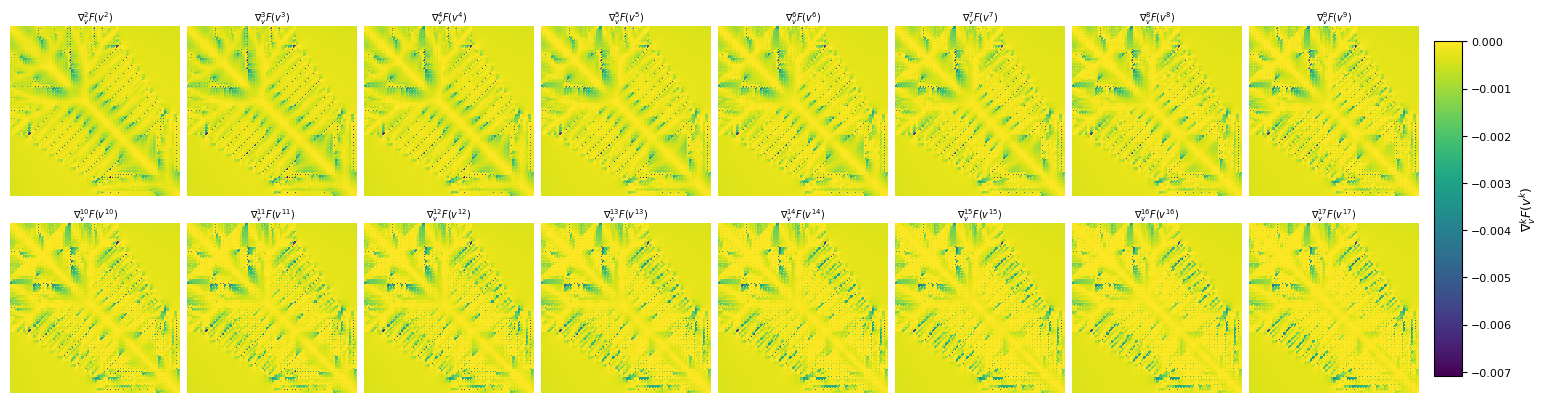

In [134]:
plot_colin_oc_gradients_grid(
admm_colin,
trial_idx=0,
oc_iter_idx=2,
grad_start=2,
grad_end=18
)

In [31]:
admmlin = ADMMNoSIMP(alpha=0.01, dim=64, base_dir="admm_no_simp/run_data_admm_gurobi")

In [ ]:
# admmlin.trial(0).series.pen[1:]

array([ 5.        ,  5.        ,  5.        ,  6.25      ,  7.8125    ,
        7.8125    ,  9.765625  ,  9.765625  , 12.20703125, 12.20703125,
       15.25878906, 15.25878906, 19.07348633, 19.07348633])

In [32]:
admmlin.trial(0).series.objective[1:]

array([140.53713583,  22.73369855,  11.35607531,  11.20484821,
        11.20484821,  18.2978426 ,   7.64019852,   8.27891059,
         8.1210929 ,   7.72569358,   7.72569358,   6.25249182,
         6.25249182,   5.58847088])

In [46]:
print(admmlin.trial(0).series.compliance[1:])

[140.53713583  22.71213605  11.33157087  11.18089294  11.18089294
  18.25484973   7.60573468   8.24417867   8.08716904   7.68460252
   7.68460252   6.21196105   6.21196105   5.5460697 ]


In [47]:
print(admmlin.trial(0).series.tv[1:])

[  0.         138.         156.82842712 153.3137085  153.3137085
 275.15432893 220.56854249 222.28427125 217.11269837 262.98275606
 262.98275606 259.39696962 259.39696962 271.36753237]


In [37]:
c5_cont = admmlin.trial(0).iters.control_cont[5]
c6_cont = admmlin.trial(0).iters.control_cont[6]

c5 = admmlin.trial(0).iters.control[5]
c6 = admmlin.trial(0).iters.control[6]

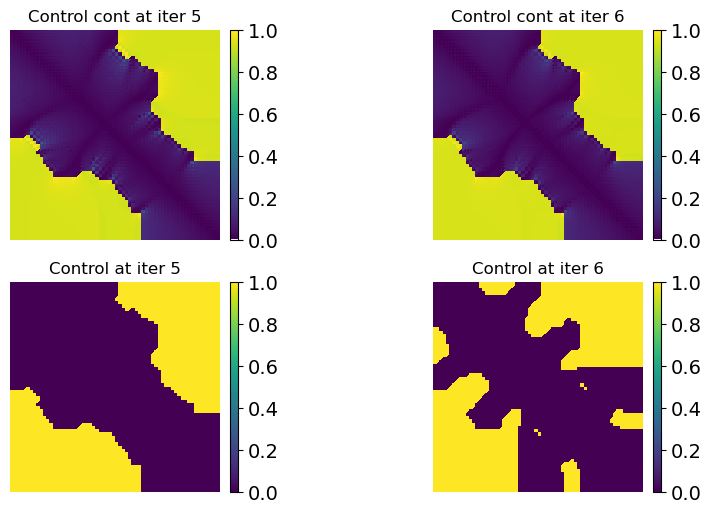

In [38]:
fig, ax = plt.subplots(figsize=(10, 6), nrows=2, ncols=2)

admmlin.plot_control(c5_cont, title="Control cont at iter 5", ax=ax[0, 0], show=False)
admmlin.plot_control(c6_cont, title="Control cont at iter 6", ax=ax[0, 1], show=False)
admmlin.plot_control(c5, title="Control at iter 5", ax=ax[1, 0], show=False)
admmlin.plot_control(c6, title="Control at iter 6", ax=ax[1, 1], show=False)

In [21]:
c12_cont = admmlin.trial(0).iters.control_cont[12]
c13_cont = admmlin.trial(0).iters.control_cont[13]

c12 = admmlin.trial(0).iters.control[12]
c13 = admmlin.trial(0).iters.control[13]


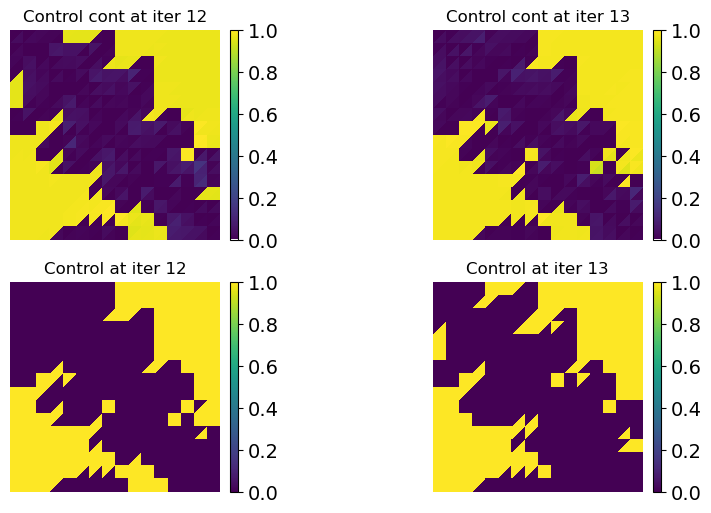

In [22]:
fig, ax = plt.subplots(figsize=(10, 6), nrows=2, ncols=2)

admmlin.plot_control(c12_cont, title="Control cont at iter 12", ax=ax[0, 0], show=False)
admmlin.plot_control(c13_cont, title="Control cont at iter 13", ax=ax[0, 1], show=False)
admmlin.plot_control(c12, title="Control at iter 12", ax=ax[1, 0], show=False)
admmlin.plot_control(c13, title="Control at iter 13", ax=ax[1, 1], show=False)

In [29]:
### b_12 -> b_13
print(admmlin.trial(0).pairs.sub1_obj_pairs[12])
#print(admmlin.trial(0).pairs.sub1_obj_pairs[13])

[1.97372447 1.39143569]


In [30]:
### a_12 -> a_13
print(admmlin.trial(0).pairs.sub2_obj_pairs[12])
#print(admmlin.trial(0).pairs.sub2_obj_pairs[13])

[1.05264009 1.03178657]


In [26]:
admmlin.trial(0).pairs.sub2_obj_pairs

array([[0.21266044, 0.21266044],
       [0.65442447, 0.35747956],
       [0.50638576, 0.47305576],
       [0.51466119, 0.51466119],
       [0.65792762, 0.6055088 ],
       [0.65861006, 0.64230175],
       [0.74127597, 0.72511034],
       [0.72437238, 0.71809982],
       [0.83241251, 0.81729404],
       [0.91874547, 0.89053119],
       [0.84701734, 0.84544559],
       [0.96184518, 0.95229133],
       [1.05264009, 1.03178657],
       [0.96656122, 0.96656122],
       [1.08730826, 1.06537375]])

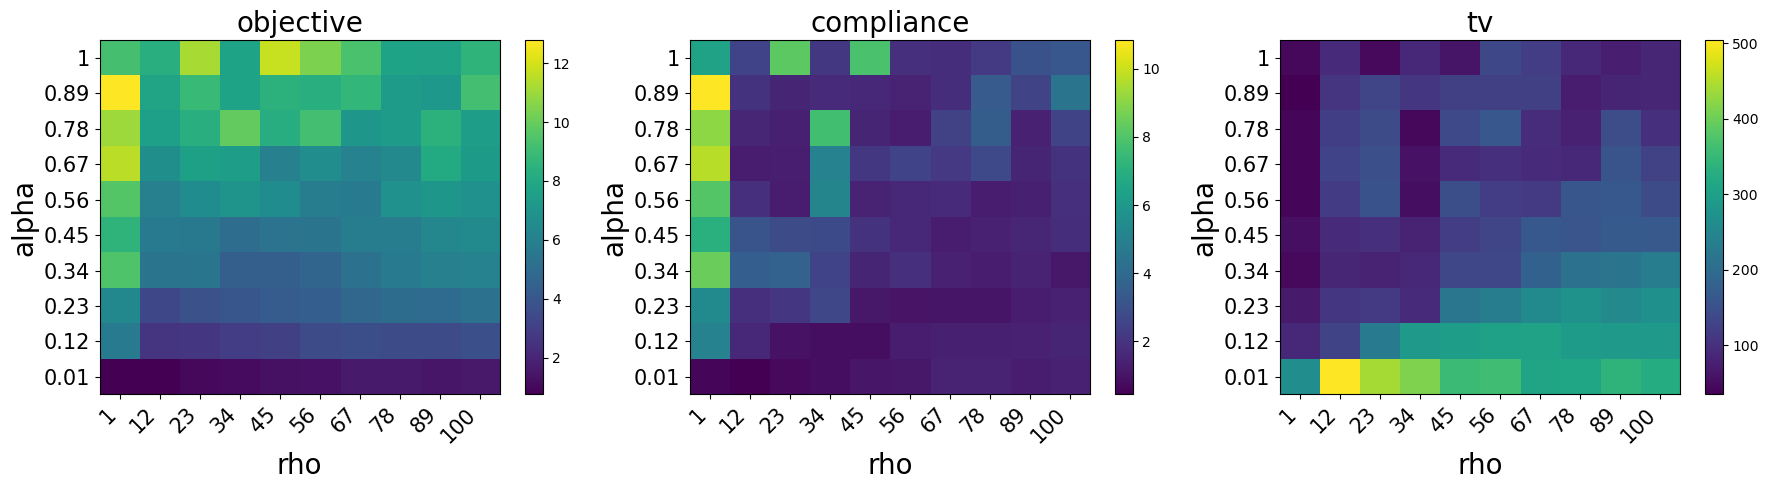

In [7]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


base_dir = "alpha_rho_sweep"


def _to_records(obj):
    """Normalize pickle payload into a list of dict records with alpha/rho/metrics."""
    records = []

    if isinstance(obj, dict):
        for k, v in obj.items():
            rec = None

            # Case 1: value already has full record fields
            if isinstance(v, dict) and ("alpha" in v) and ("rho" in v):
                rec = dict(v)

            # Case 2: key carries (alpha, rho), value has metrics
            elif isinstance(k, (tuple, list)) and len(k) >= 2 and isinstance(v, dict):
                rec = {
                    "alpha": float(k[0]),
                    "rho": float(k[1]),
                    "objective": v.get("objective", np.nan),
                    "compliance": v.get("compliance", np.nan),
                    "tv": v.get("tv", np.nan),
                }

            # Case 3: nested list/tuple payloads
            elif isinstance(v, (list, tuple)):
                for item in v:
                    if isinstance(item, dict) and ("alpha" in item) and ("rho" in item):
                        records.append(dict(item))

            if rec is not None:
                records.append(rec)

    elif isinstance(obj, (list, tuple)):
        for item in obj:
            if isinstance(item, dict) and ("alpha" in item) and ("rho" in item):
                records.append(dict(item))

    return records


def _build_grids(records):
    alphas = np.array(sorted({float(r["alpha"]) for r in records}), dtype=float)
    rhos = np.array(sorted({float(r["rho"]) for r in records}), dtype=float)

    A = len(alphas)
    R = len(rhos)

    grids = {
        "objective": np.full((A, R), np.nan, dtype=float),
        "compliance": np.full((A, R), np.nan, dtype=float),
        "tv": np.full((A, R), np.nan, dtype=float),
    }

    a_to_i = {a: i for i, a in enumerate(alphas)}
    r_to_j = {r: j for j, r in enumerate(rhos)}

    for rec in records:
        i = a_to_i[float(rec["alpha"])]
        j = r_to_j[float(rec["rho"])]
        for m in grids:
            grids[m][i, j] = float(rec.get(m, np.nan))

    return alphas, rhos, grids


def plot_alpha_rho_heatmaps(fname, base_dir="alpha_rho_sweep"):
    p = os.path.join(base_dir, fname)
    with open(p, "rb") as f:
        payload = pickle.load(f)

    records = _to_records(payload)
    if len(records) == 0:
        raise ValueError(f"No alpha/rho records found in {p}")

    alphas, rhos, grids = _build_grids(records)
    metrics = ["objective", "compliance", "tv"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), squeeze=False)

    for col, metric in enumerate(metrics):
        ax = axes[0, col]
        im = ax.imshow(
            grids[metric],
            origin="lower",
            aspect="auto",
            cmap="viridis",
        )

        ax.set_title(f"{metric}", fontsize=20)
        ax.set_xlabel("rho", fontsize=20)
        ax.set_ylabel("alpha", fontsize=20)

        ax.set_xticks(np.arange(len(rhos)))
        ax.set_xticklabels([f"{x:.3g}" for x in rhos], rotation=45, ha="right", fontsize=15)
        ax.set_yticks(np.arange(len(alphas)))
        ax.set_yticklabels([f"{x:.3g}" for x in alphas], fontsize=15)

        cbar = fig.colorbar(im, ax=ax)
        #cbar.ax.set_ylabel(metric, fontsize=15)

    plt.tight_layout()
    plt.show()


# Figure 1: ADMM
plot_alpha_rho_heatmaps("results_alpha_rho_sweep_admm.pkl", base_dir=base_dir)

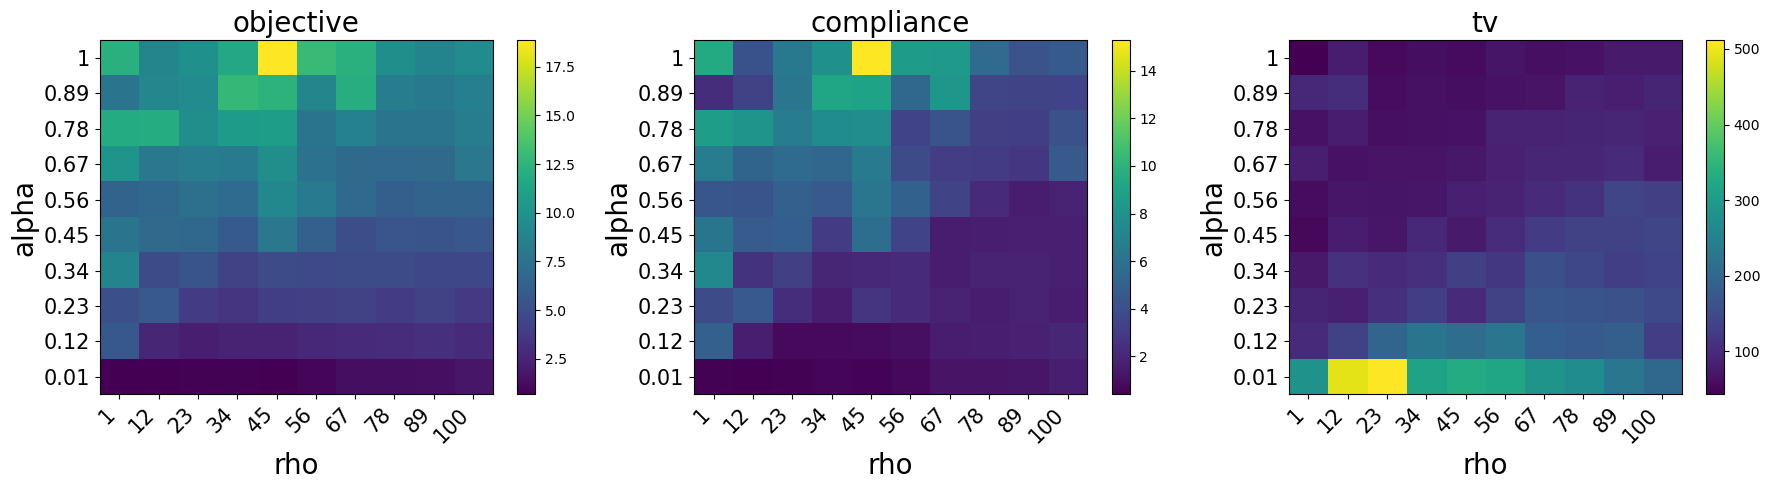

In [8]:
# Figure 2: ADMM-Colin
plot_alpha_rho_heatmaps("results_alpha_rho_sweep_admm-colin.pkl", base_dir=base_dir)

In [10]:
# Get control for a given 2D heatmap grid index (alpha_idx, rho_idx), both 0-based

def get_control_from_grid_index_2d(grid_index_2d, fname, base_dir="alpha_rho_sweep"):
    p = os.path.join(base_dir, fname)
    with open(p, "rb") as f:
        payload = pickle.load(f)

    records = _to_records(payload)
    if len(records) == 0:
        raise ValueError(f"No alpha/rho records found in {p}")

    alphas, rhos, _ = _build_grids(records)

    if not isinstance(grid_index_2d, (tuple, list)) or len(grid_index_2d) != 2:
        raise ValueError("grid_index_2d must be a tuple/list: (alpha_idx, rho_idx)")

    i = int(grid_index_2d[0])  # alpha index
    j = int(grid_index_2d[1])  # rho index

    if i < 0 or i >= len(alphas):
        raise ValueError(f"alpha_idx must be in [0, {len(alphas) - 1}], got {i}")
    if j < 0 or j >= len(rhos):
        raise ValueError(f"rho_idx must be in [0, {len(rhos) - 1}], got {j}")

    alpha_sel = float(alphas[i])
    rho_sel = float(rhos[j])

    match = None
    for rec in records:
        if abs(float(rec["alpha"]) - alpha_sel) < 1e-12 and abs(float(rec["rho"]) - rho_sel) < 1e-12:
            match = rec
            break

    if match is None:
        raise ValueError("Record not found for selected alpha/rho")
    if "control" not in match:
        raise ValueError("Selected record does not contain 'control'")

    control = np.asarray(match["control"], dtype=float)

    out = {
        "grid_index_2d": (i, j),
        "alpha": alpha_sel,
        "rho": rho_sel,
        "control": control,
        "objective": float(match.get("objective", np.nan)),
        "compliance": float(match.get("compliance", np.nan)),
        "tv": float(match.get("tv", np.nan)),
    }
    return out

In [24]:
# Examples: 2D grid indices (alpha_idx, rho_idx)
admm = get_control_from_grid_index_2d((0, 0), "results_alpha_rho_sweep_admm.pkl", base_dir=base_dir)
admm_colin = get_control_from_grid_index_2d((9, 4), "results_alpha_rho_sweep_admm-colin.pkl", base_dir=base_dir)

In [25]:
from admmcolinviz import plot_control_field as plt_admm_colin
from admmviz import plot_control_field as plt_admm

(<Axes: title={'center': 'final control'}>,
 <matplotlib.collections.PolyCollection at 0x749c7e905a50>)

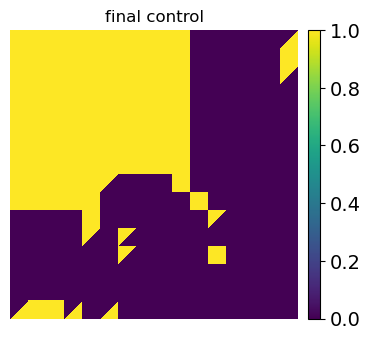

In [26]:
figsize = (4, 4)
fig, ax = plt.subplots(figsize=figsize)
plt_admm_colin(admm_colin["control"], dim=16, title="final control", figsize=figsize, ax=ax, show=True)